# LIBRARY

In [775]:
%pip install scikit-plot -q
%pip install scipy -q

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [776]:
import numpy as np
import scipy
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree, DecisionTreeRegressor
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold
from scikitplot.metrics import plot_roc
from scikitplot.metrics import plot_precision_recall
from sklearn.tree._tree import TREE_LEAF
from sklearn.tree import plot_tree, DecisionTreeRegressor
import matplotlib.pyplot as plt

In [777]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    mean_squared_error,
    mean_absolute_error, 
    r2_score
)

# IMPORT CONTROL DATA SET 

In [778]:
file_path = "../1.DATASET/CMI_V2_CONTROL.csv"
df=pd.read_csv(file_path)
df

,id,Basic_Demos-Age,Basic_Demos-Sex,CGAS-CGAS_Score,Physical-BMI,Physical-Height,Physical-Weight,BIA-BIA_BMR,Physical-HeartRate,Fitness_Endurance-Max_Stage,...,BIA-BIA_Frame_num,BIA-BIA_SMM,BIA-BIA_TBW,SDS-SDS_Total_T,PreInt_EduHx-computerinternet_hoursday,sii,Physical-MAP_CAL,FGC-FGC_CORE_CAL,FGC-FGC_GS_CAL,FGC-FGC_SR_CAL
0,1,9,0,NaN,14.035590,48.00,46.0,936.656,70.0,NaN,...,1.0,15.4107,27.0552,64.0,0.0,0.0,90.666667,8.000000,18.204545,11.000000
1,3,9,0,71.0,18.292347,56.00,81.6,1131.430,97.0,6.0,...,2.0,26.4798,45.9966,45.0,0.0,1.0,79.000000,23.000000,18.204545,7.000000
2,5,13,1,50.0,22.279952,59.50,112.2,1330.970,73.0,5.0,...,2.0,35.3804,63.1265,56.0,0.0,1.0,74.000000,18.000000,17.200000,10.500000
3,6,10,0,NaN,19.660760,55.00,84.6,1135.860,83.0,NaN,...,2.0,26.1957,47.2211,40.0,3.0,0.0,136.333333,11.000000,16.840263,11.000000
4,7,10,1,65.0,16.861286,59.25,84.2,1180.040,90.0,5.0,...,2.0,28.7680,50.4767,55.0,2.0,0.0,86.000000,14.662915,11.850000,7.682875
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1852,3952,15,0,40.0,26.364710,70.50,186.4,1719.310,74.0,5.0,...,3.0,54.2027,91.4887,90.0,3.0,1.0,117.333333,23.714789,26.417470,8.527654
1853,3953,8,0,65.0,17.139810,52.50,67.2,1035.270,65.0,NaN,...,1.0,20.2645,36.7181,58.0,2.0,0.0,77.333333,10.568299,18.526452,9.000000
1854,3954,7,1,NaN,13.927006,48.50,46.6,966.287,75.0,5.0,...,1.0,18.0937,30.0453,67.0,0.0,1.0,78.333333,9.540221,18.909726,8.750000
1855,3955,13,0,60.0,16.362460,59.50,82.4,1206.880,70.0,NaN,...,1.0,29.7790,52.8320,50.0,1.0,1.0,82.000000,26.000000,18.950000,8.500000


In [779]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1857 entries, 0 to 1856
Data columns (total 32 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   id                                      1857 non-null   int64  
 1   Basic_Demos-Age                         1857 non-null   int64  
 2   Basic_Demos-Sex                         1857 non-null   int64  
 3   CGAS-CGAS_Score                         1679 non-null   float64
 4   Physical-BMI                            1857 non-null   float64
 5   Physical-Height                         1857 non-null   float64
 6   Physical-Weight                         1857 non-null   float64
 7   BIA-BIA_BMR                             1856 non-null   float64
 8   Physical-HeartRate                      1853 non-null   float64
 9   Fitness_Endurance-Max_Stage             1206 non-null   float64
 10  FGC-FGC_TL                              1708 non-null   floa

# Data Cleaning

## Removing useless variables

In [780]:
column2drop = ['id']
df.drop(column2drop, axis=1, inplace=True)

In [781]:
df.head()

,Basic_Demos-Age,Basic_Demos-Sex,CGAS-CGAS_Score,Physical-BMI,Physical-Height,Physical-Weight,BIA-BIA_BMR,Physical-HeartRate,Fitness_Endurance-Max_Stage,FGC-FGC_TL,...,BIA-BIA_Frame_num,BIA-BIA_SMM,BIA-BIA_TBW,SDS-SDS_Total_T,PreInt_EduHx-computerinternet_hoursday,sii,Physical-MAP_CAL,FGC-FGC_CORE_CAL,FGC-FGC_GS_CAL,FGC-FGC_SR_CAL
0,9,0,NaN,14.035590,48.00,46.0,936.656,70.0,NaN,3.0,...,1.0,15.4107,27.0552,64.0,0.0,0.0,90.666667,8.000000,18.204545,11.000000
1,9,0,71.0,18.292347,56.00,81.6,1131.430,97.0,6.0,7.0,...,2.0,26.4798,45.9966,45.0,0.0,1.0,79.000000,23.000000,18.204545,7.000000
2,13,1,50.0,22.279952,59.50,112.2,1330.970,73.0,5.0,8.0,...,2.0,35.3804,63.1265,56.0,0.0,1.0,74.000000,18.000000,17.200000,10.500000
3,10,0,NaN,19.660760,55.00,84.6,1135.860,83.0,NaN,11.0,...,2.0,26.1957,47.2211,40.0,3.0,0.0,136.333333,11.000000,16.840263,11.000000
4,10,1,65.0,16.861286,59.25,84.2,1180.040,90.0,5.0,4.0,...,2.0,28.7680,50.4767,55.0,2.0,0.0,86.000000,14.662915,11.850000,7.682875


In [782]:
df.columns

Index(['Basic_Demos-Age', 'Basic_Demos-Sex', 'CGAS-CGAS_Score', 'Physical-BMI',
       'Physical-Height', 'Physical-Weight', 'BIA-BIA_BMR',
       'Physical-HeartRate', 'Fitness_Endurance-Max_Stage', 'FGC-FGC_TL',
       'BIA-BIA_Activity_Level_num', 'BIA-BIA_BMI', 'BIA-BIA_BMC',
       'BIA-BIA_DEE', 'BIA-BIA_ECW', 'BIA-BIA_ICW', 'BIA-BIA_FFMI',
       'BIA-BIA_FFM', 'BIA-BIA_FMI', 'BIA-BIA_Fat', 'BIA-BIA_LST',
       'BIA-BIA_Frame_num', 'BIA-BIA_SMM', 'BIA-BIA_TBW', 'SDS-SDS_Total_T',
       'PreInt_EduHx-computerinternet_hoursday', 'sii', 'Physical-MAP_CAL',
       'FGC-FGC_CORE_CAL', 'FGC-FGC_GS_CAL', 'FGC-FGC_SR_CAL'],
      dtype='object')

# TARGET VARIABLES

## TARGET VARIABLE Physical-Height

In [783]:
df_height = df[[ 'Physical-BMI','Physical-Height', 'Physical-Weight']].copy()


In [784]:
df_height.isnull().sum()

Physical-BMI       0
Physical-Height    0
Physical-Weight    0
dtype: int64

In [785]:
df_height[df_height['Physical-Height']==0]

,Physical-BMI,Physical-Height,Physical-Weight


### Partitioning

In [786]:
attributes = [col for col in df_height.columns if col != 'Physical-Height']
X = df_height[attributes].values
y = np.array(df_height['Physical-Height'])

In [787]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)


In [788]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(1392, 2) (465, 2) (1392,) (465,)


In [789]:
df_height.shape

(1857, 3)

### Randomized Search

In [790]:
# options for scoring
#scoring='neg_mean_squared_error'      # most common, minimizes large errors
#scoring='neg_mean_absolute_error'     # more robust to outliers
#scoring='neg_root_mean_squared_error' # directly in target units
#scoring='r2'                          # maximizes explained variance

In [791]:
param_list = {
    'max_depth': [None] + list(np.arange(2, 50)),
    'min_samples_split': [0.001, 0.002, 0.01, 0.05, 0.1, 0.2],
    'min_samples_leaf': [5, 10, 20, 30, 50, 100, 150],
    'criterion': ['squared_error', 'absolute_error', 'friedman_mse']  
}

dt_reg_height = DecisionTreeRegressor()  

random_search = RandomizedSearchCV(
    DecisionTreeRegressor(),    
    param_distributions=param_list,
    cv=KFold(n_splits=5, shuffle=True, random_state=0), 
    scoring='neg_mean_squared_error' ,   
    n_jobs=-1,
    refit=True,
    n_iter=300,
)

random_search.fit(X_train, y_train)
dt_reg_height = random_search.best_estimator_

In [792]:
print(random_search.best_params_, random_search.best_score_)

{'min_samples_split': 0.001, 'min_samples_leaf': 5, 'max_depth': 35, 'criterion': 'squared_error'} -1.4491228502718585


In [793]:
dt_reg_height = random_search.best_estimator_
dt_reg_height.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=35, min_samples_leaf=5, min_samples_split=0.001)

In [794]:
y_pred = dt_reg_height.predict(X_test)

print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}") # Typical error
print(f"MAE  : {mean_absolute_error(y_test, y_pred):.4f}")  #Average Error
print(f"MSE  : {mean_squared_error(y_test, y_pred):.4f}")  #Average Error
print(f"R²   : {r2_score(y_test, y_pred):.4f}") # variance in the target variable

RMSE : 1.0631
MAE  : 0.7167
MSE  : 1.1301
R²   : 0.9785


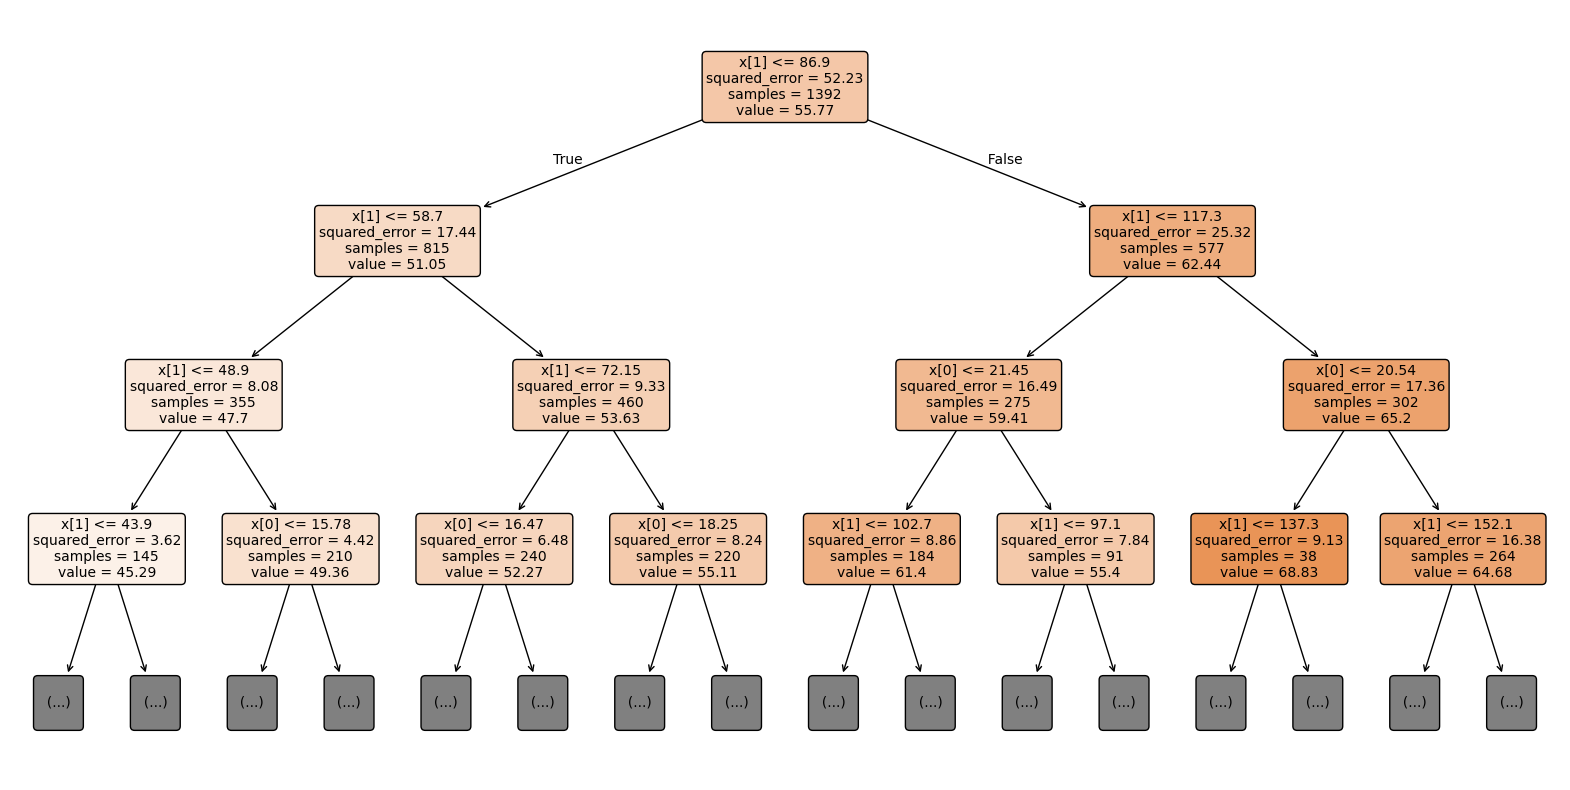

In [795]:
plt.figure(figsize=(20, 10))

plot_tree(
    dt_reg_height,
    filled=True,
    rounded=True,
    fontsize=10,
    precision=2,
    max_depth = 3
)

plt.show()

Idx | Actual | Predicted | Error
----------------------------------------
  77 | 41.5000 |   48.3333 | 6.8333
 311 | 49.0000 |   55.5071 | 6.5071
  24 | 77.5000 |   71.7000 | 5.8000
 366 | 70.5000 |   66.7000 | 3.8000
 235 | 70.0000 |   73.6786 | 3.6786
 272 | 70.0000 |   73.6786 | 3.6786
  99 | 64.0000 |   60.8000 | 3.2000
  44 | 70.5000 |   67.4000 | 3.1000
 415 | 70.5000 |   67.4000 | 3.1000
 210 | 50.0000 |   52.8600 | 2.8600


C:\Users\paula\AppData\Local\Temp\ipykernel_11332\1016786874.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


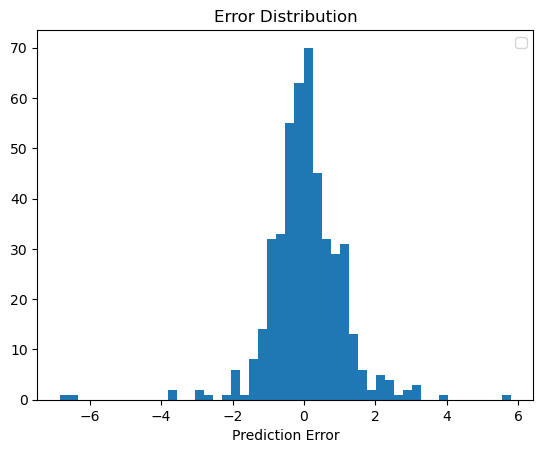

In [796]:
errors = np.abs(y_test - y_pred)

# Top 10 worst predictions
worst_indices = np.argsort(errors)[-10:][::-1]

print("Idx | Actual | Predicted | Error")
print("-" * 40)
for i in worst_indices:
    print(f"{i:4d} | {y_test[i]:7.4f} | {y_pred[i]:9.4f} | {errors[i]:.4f}")

# Error distribution plot
plt.hist(y_test - y_pred, bins=50)
plt.xlabel('Prediction Error')
plt.title('Error Distribution')
plt.legend()
plt.show()

### Feature Importance

In [797]:
zipped = zip(attributes, dt_reg_height.feature_importances_)
zipped = sorted(zipped, key=lambda x: x[1], reverse=True)
for col, imp in zipped:
    print(col, imp)

Physical-Weight 0.8721410868395213
Physical-BMI 0.12785891316047862


## TARGET VARIABLE BIA-BIA_TBW

In [798]:
df_BIA_TBW = df[['BIA-BIA_ECW', 'BIA-BIA_ICW','BIA-BIA_TBW']].copy()



In [799]:
#df_BIA_TBW=df_BIA_TBW.dropna(subset=['BIA-BIA_FFMI'])

In [800]:
df_BIA_TBW.isnull().sum()

BIA-BIA_ECW    0
BIA-BIA_ICW    0
BIA-BIA_TBW    0
dtype: int64

In [801]:
df_BIA_TBW[df_BIA_TBW['BIA-BIA_TBW']==0]

,BIA-BIA_ECW,BIA-BIA_ICW,BIA-BIA_TBW


### Partitioning

In [802]:
attributes = [col for col in df_BIA_TBW.columns if col != 'BIA-BIA_TBW']
X = df_BIA_TBW[attributes].values
y = np.array(df_BIA_TBW['BIA-BIA_TBW'])

In [803]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)


In [804]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(1392, 2) (465, 2) (1392,) (465,)


In [805]:
df_BIA_TBW.shape

(1857, 3)

### Randomized Search

In [806]:
# options for scoring
#scoring='neg_mean_squared_error'      # most common, minimizes large errors
#scoring='neg_mean_absolute_error'     # more robust to outliers
#scoring='neg_root_mean_squared_error' # directly in target units
#scoring='r2'                          # maximizes explained variance

In [807]:
param_list = {
    'max_depth': [None] + list(np.arange(2, 50)),
    'min_samples_split': [0.001, 0.002, 0.01, 0.05, 0.1, 0.2],
    'min_samples_leaf': [5, 10, 20, 30, 50, 100, 150],
    'criterion': ['squared_error', 'absolute_error', 'friedman_mse']  
}

dt_reg_TBW = DecisionTreeRegressor()  

random_search = RandomizedSearchCV(
    DecisionTreeRegressor(),    
    param_distributions=param_list,
    cv=KFold(n_splits=5, shuffle=True, random_state=0), 
    scoring='neg_mean_squared_error' ,   
    n_jobs=-1,
    refit=True,
    n_iter=300,
)

random_search.fit(X_train, y_train)
dt_reg_TBW = random_search.best_estimator_

In [808]:
print(random_search.best_params_, random_search.best_score_)

{'min_samples_split': 0.002, 'min_samples_leaf': 5, 'max_depth': 23, 'criterion': 'friedman_mse'} -1.5664493740721024


In [809]:
dt_reg_TBW = random_search.best_estimator_
dt_reg_TBW.fit(X_train, y_train)

DecisionTreeRegressor(criterion='friedman_mse', max_depth=23,
                      min_samples_leaf=5, min_samples_split=0.002)

In [810]:
y_pred = dt_reg_TBW.predict(X_test)

print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}") # Typical error
print(f"MAE  : {mean_absolute_error(y_test, y_pred):.4f}")  #Average Error
print(f"MSE  : {mean_squared_error(y_test, y_pred):.4f}")  #Average Error
print(f"R²   : {r2_score(y_test, y_pred):.4f}") # variance in the target variable

RMSE : 0.9783
MAE  : 0.6263
MSE  : 0.9570
R²   : 0.9972


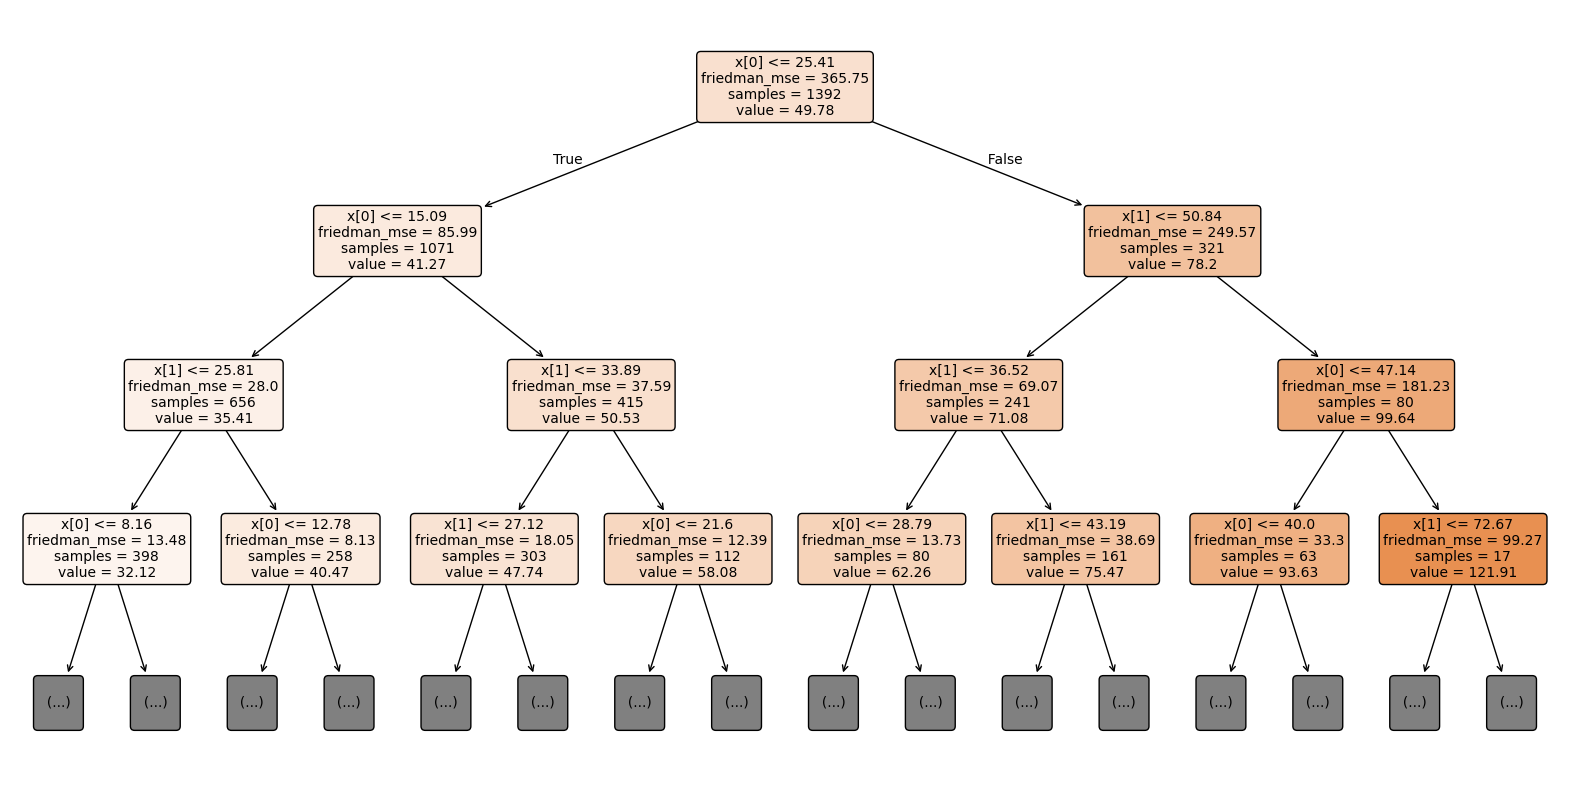

In [811]:
plt.figure(figsize=(20, 10))

plot_tree(
    dt_reg_TBW,
    filled=True,
    rounded=True,
    fontsize=10,
    precision=2,
    max_depth = 3
)

plt.show()

Idx | Actual | Predicted | Error
----------------------------------------
  24 | 125.9560 |  120.2422 | 5.7138
 405 | 22.8800 |   28.0992 | 5.2192
 196 | 81.5263 |   86.3486 | 4.8223
 186 | 60.2056 |   56.1244 | 4.0812
 121 | 107.0920 |  103.3416 | 3.7504
 145 | 83.5786 |   80.0303 | 3.5483
 162 | 74.0409 |   77.4125 | 3.3716
  93 | 123.5600 |  120.2422 | 3.3178
 366 | 132.1710 |  135.4846 | 3.3136
 427 | 74.5008 |   71.5858 | 2.9150


C:\Users\paula\AppData\Local\Temp\ipykernel_11332\1016786874.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


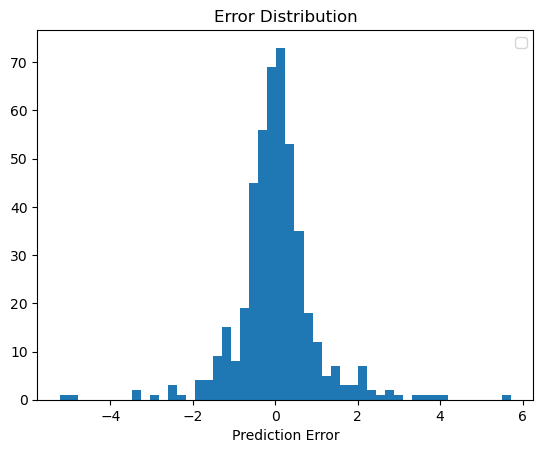

In [812]:
errors = np.abs(y_test - y_pred)

# Top 10 worst predictions
worst_indices = np.argsort(errors)[-10:][::-1]

print("Idx | Actual | Predicted | Error")
print("-" * 40)
for i in worst_indices:
    print(f"{i:4d} | {y_test[i]:7.4f} | {y_pred[i]:9.4f} | {errors[i]:.4f}")

# Error distribution plot
plt.hist(y_test - y_pred, bins=50)
plt.xlabel('Prediction Error')
plt.title('Error Distribution')
plt.legend()
plt.show()

### Feature Importance

In [813]:
zipped = zip(attributes, dt_reg_TBW.feature_importances_)
zipped = sorted(zipped, key=lambda x: x[1], reverse=True)
for col, imp in zipped:
    print(col, imp)

BIA-BIA_ECW 0.825842768819611
BIA-BIA_ICW 0.17415723118038887


## TARGET VARIABLE BIA-BIA_Fat

In [814]:
df_BIA_Fat = df[['Physical-Weight', 
                'Physical-Height','BIA-BIA_FMI',
                'BIA-BIA_Fat'                          
]].copy()



In [815]:
#df_BIA_Fat=df_BIA_Fat.dropna(subset=['BIA-BIA_FFMI','Physical-HeartRate'])

In [816]:
df_BIA_Fat.isnull().sum()

Physical-Weight    0
Physical-Height    0
BIA-BIA_FMI        0
BIA-BIA_Fat        0
dtype: int64

### Partitioning

In [817]:
attributes = [col for col in df_BIA_Fat.columns if col != 'BIA-BIA_Fat']
X = df_BIA_Fat[attributes].values
y = np.array(df_BIA_Fat['BIA-BIA_Fat'])

In [818]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)


In [819]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(1392, 3) (465, 3) (1392,) (465,)


In [820]:
df_BIA_Fat.shape

(1857, 4)

### Randomized Search

In [821]:
# options for scoring
#scoring='neg_mean_squared_error'      # most common, minimizes large errors
#scoring='neg_mean_absolute_error'     # more robust to outliers
#scoring='neg_root_mean_squared_error' # directly in target units
#scoring='r2'                          # maximizes explained variance

In [822]:
param_list = {
    'max_depth': [None] + list(np.arange(2, 50)),
    'min_samples_split': [0.001, 0.002, 0.01, 0.05, 0.1, 0.2],
    'min_samples_leaf': [5, 10, 20, 30, 50, 100, 150],
    'criterion': ['squared_error', 'absolute_error', 'friedman_mse']  
}

dt_reg_FAT = DecisionTreeRegressor()  

random_search = RandomizedSearchCV(
    DecisionTreeRegressor(),    
    param_distributions=param_list,
    cv=KFold(n_splits=5, shuffle=True, random_state=0), 
    scoring='neg_mean_squared_error' ,   
    n_jobs=-1,
    refit=True,
    n_iter=300,
)

random_search.fit(X_train, y_train)
dt_reg_FAT = random_search.best_estimator_

In [823]:
print(random_search.best_params_, random_search.best_score_)

{'min_samples_split': 0.002, 'min_samples_leaf': 5, 'max_depth': 25, 'criterion': 'absolute_error'} -8.517535762921952


In [824]:
dt_reg_FAT = random_search.best_estimator_
dt_reg_FAT.fit(X_train, y_train)

DecisionTreeRegressor(criterion='absolute_error', max_depth=25,
                      min_samples_leaf=5, min_samples_split=0.002)

In [825]:
y_pred = dt_reg_FAT.predict(X_test)

print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}") # Typical error
print(f"MAE  : {mean_absolute_error(y_test, y_pred):.4f}")  #Average Error
print(f"MSE  : {mean_squared_error(y_test, y_pred):.4f}")  #Average Error
print(f"R²   : {r2_score(y_test, y_pred):.4f}") # variance in the target variable

RMSE : 2.1460
MAE  : 1.1939
MSE  : 4.6054
R²   : 0.9866


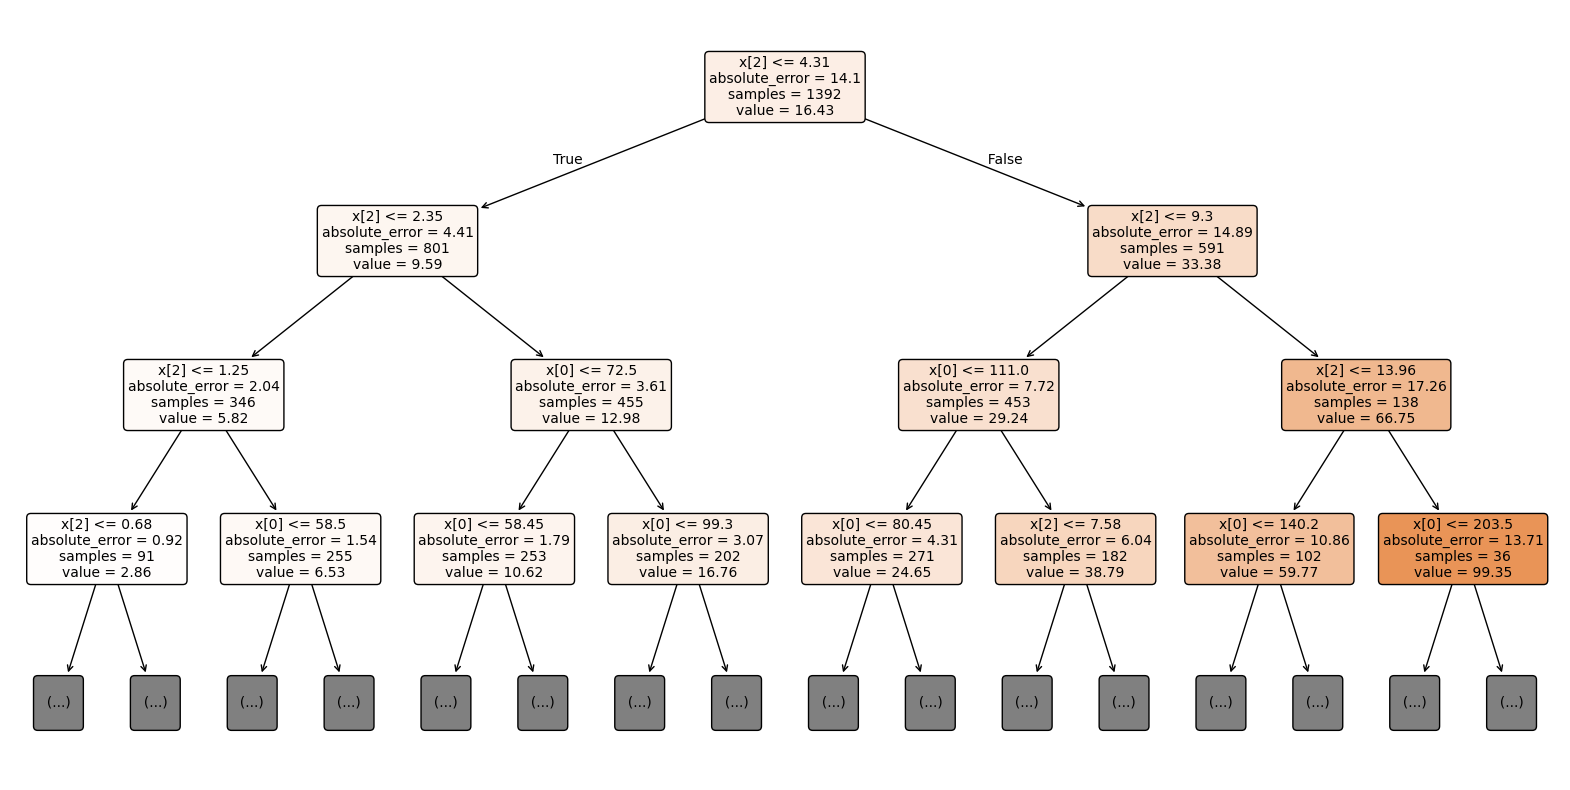

In [826]:
plt.figure(figsize=(20, 10))

plot_tree(
    dt_reg_FAT,
    filled=True,
    rounded=True,
    fontsize=10,
    precision=2,
    max_depth = 3
)

plt.show()

Idx | Actual | Predicted | Error
----------------------------------------
 366 | 126.0100 |  105.8120 | 20.1980
 311 | 58.6013 |   75.4429 | 16.8416
 145 | 108.8070 |  116.9160 | 8.1090
 127 | 81.4070 |   88.6792 | 7.2722
 130 | 57.1916 |   50.0139 | 7.1777
 393 | 56.1160 |   49.2732 | 6.8428
  98 | 42.4451 |   35.7149 | 6.7302
   9 | 71.3179 |   64.5942 | 6.7237
  18 | 39.2171 |   45.5311 | 6.3139
 293 | 75.8225 |   69.7108 | 6.1117


C:\Users\paula\AppData\Local\Temp\ipykernel_11332\1016786874.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


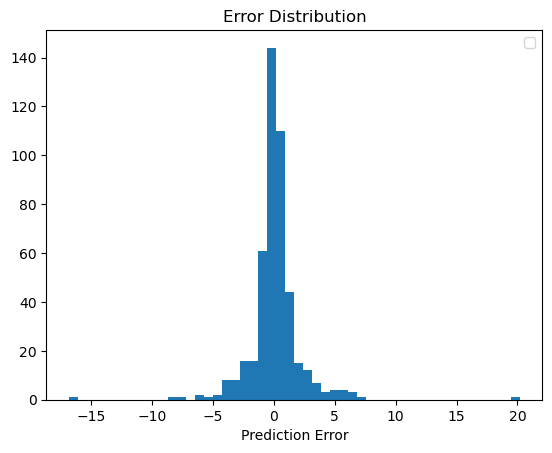

In [827]:
errors = np.abs(y_test - y_pred)

# Top 10 worst predictions
worst_indices = np.argsort(errors)[-10:][::-1]

print("Idx | Actual | Predicted | Error")
print("-" * 40)
for i in worst_indices:
    print(f"{i:4d} | {y_test[i]:7.4f} | {y_pred[i]:9.4f} | {errors[i]:.4f}")

# Error distribution plot
plt.hist(y_test - y_pred, bins=50)
plt.xlabel('Prediction Error')
plt.title('Error Distribution')
plt.legend()
plt.show()

### Feature Importance

In [828]:
zipped = zip(attributes, dt_reg_FAT.feature_importances_)
zipped = sorted(zipped, key=lambda x: x[1], reverse=True)
for col, imp in zipped:
    print(col, imp)

BIA-BIA_FMI 0.7620707003897588
Physical-Weight 0.2163908028901109
Physical-Height 0.021538496720130272


## TARGET VARIABLE BIA-BIA_DEE

In [829]:
df_BIA_DEE = df[[
    'BIA-BIA_DEE',
    'BIA-BIA_BMR',                  
    'BIA-BIA_Activity_Level_num',   
    'Basic_Demos-Sex',              
    'Basic_Demos-Age',              
    'Physical-Weight',             
    'Physical-Height' ,
    'BIA-BIA_TBW'  ,
    'BIA-BIA_Fat'          
]]



In [830]:
df_BIA_DEE=df_BIA_DEE.dropna(subset=['BIA-BIA_DEE','BIA-BIA_BMR'])

In [831]:
df_BIA_DEE.isnull().sum()

BIA-BIA_DEE                   0
BIA-BIA_BMR                   0
BIA-BIA_Activity_Level_num    0
Basic_Demos-Sex               0
Basic_Demos-Age               0
Physical-Weight               0
Physical-Height               0
BIA-BIA_TBW                   0
BIA-BIA_Fat                   0
dtype: int64

### Partitioning

In [832]:
attributes = [col for col in df_BIA_DEE.columns if col != 'BIA-BIA_DEE']
X = df_BIA_DEE[attributes].values
y = np.array(df_BIA_DEE['BIA-BIA_DEE'])

In [833]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)


In [834]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(1392, 8) (464, 8) (1392,) (464,)


In [835]:
df_BIA_DEE.shape

(1856, 9)

### Randomized Search

In [836]:
# options for scoring
#scoring='neg_mean_squared_error'      # most common, minimizes large errors
#scoring='neg_mean_absolute_error'     # more robust to outliers
#scoring='neg_root_mean_squared_error' # directly in target units
#scoring='r2'                          # maximizes explained variance

In [837]:
param_list = {
    'max_depth': [None] + list(np.arange(2, 50)),
    'min_samples_split': [0.001, 0.002, 0.01, 0.05, 0.1, 0.2],
    'min_samples_leaf': [5, 10, 20, 30, 50, 100, 150],
    'criterion': ['squared_error', 'absolute_error', 'friedman_mse']  
}

dt_reg_DEE = DecisionTreeRegressor()  

random_search = RandomizedSearchCV(
    DecisionTreeRegressor(),    
    param_distributions=param_list,
    cv=KFold(n_splits=5, shuffle=True, random_state=0), 
    scoring='neg_mean_squared_error' ,   
    n_jobs=-1,
    refit=True,
    n_iter=300,
)

random_search.fit(X_train, y_train)
dt_reg_DEE = random_search.best_estimator_

In [838]:
print(random_search.best_params_, random_search.best_score_)

{'min_samples_split': 0.002, 'min_samples_leaf': 5, 'max_depth': 33, 'criterion': 'squared_error'} -6498.620297664873


In [839]:
dt_reg_DEE = random_search.best_estimator_
dt_reg_DEE.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=33, min_samples_leaf=5, min_samples_split=0.002)

In [840]:
y_pred = dt_reg_DEE.predict(X_test)

print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}") # Typical error
print(f"MAE  : {mean_absolute_error(y_test, y_pred):.4f}")  #Average Error
print(f"MSE  : {mean_squared_error(y_test, y_pred):.4f}")  #Average Error
print(f"R²   : {r2_score(y_test, y_pred):.4f}") # variance in the target variable

RMSE : 65.4777
MAE  : 29.9734
MSE  : 4287.3234
R²   : 0.9844


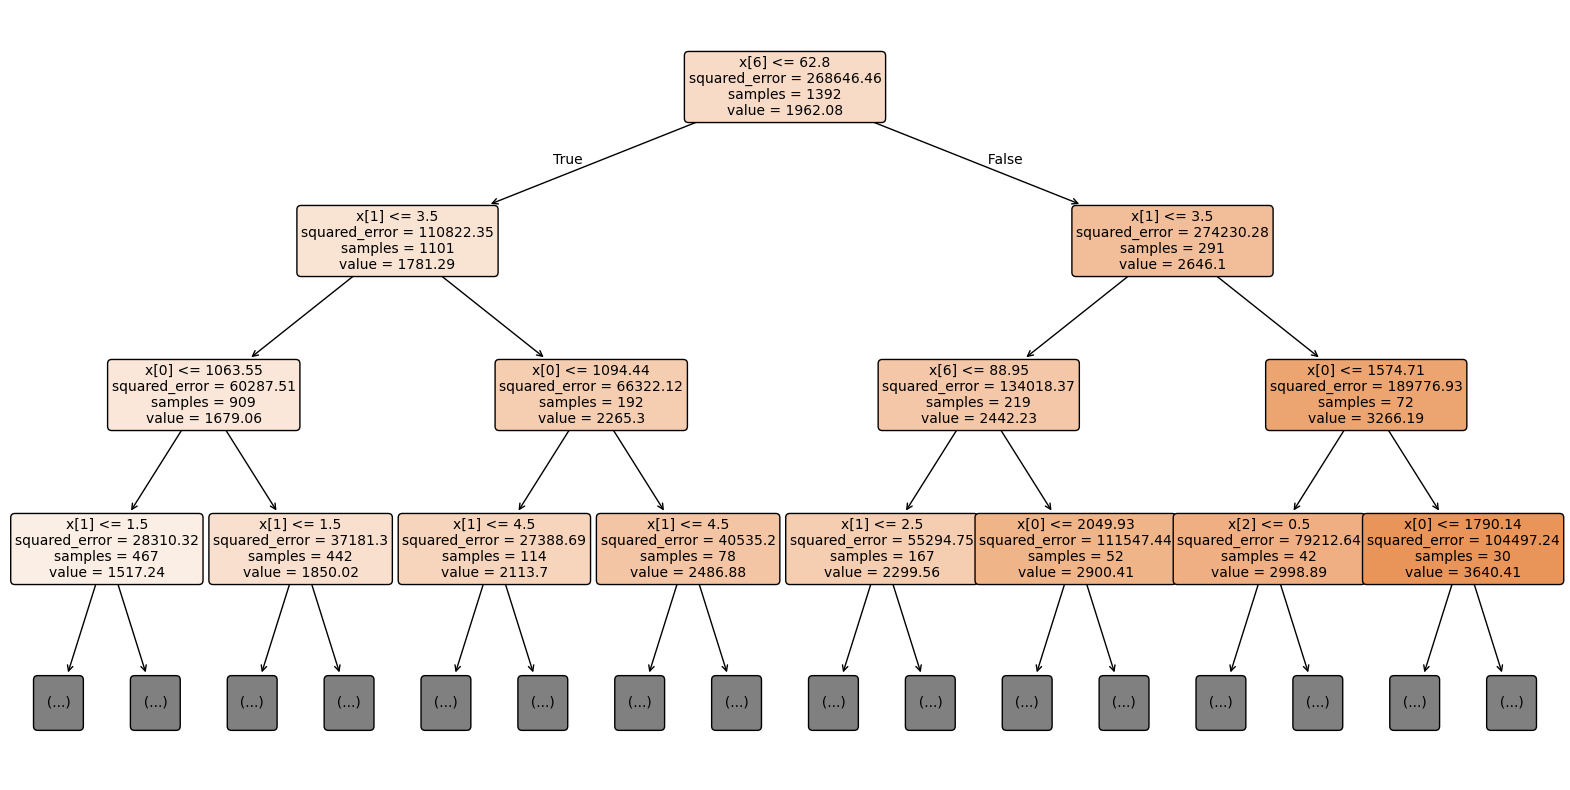

In [841]:
plt.figure(figsize=(20, 10))

plot_tree(
    dt_reg_DEE,
    filled=True,
    rounded=True,
    fontsize=10,
    precision=2,
    max_depth = 3
)

plt.show()

Idx | Actual | Predicted | Error
----------------------------------------
 136 | 2818.9700 | 3405.0000 | 586.0300
 140 | 4517.1300 | 4102.0500 | 415.0800
 363 | 4140.3100 | 3725.6486 | 414.6614
 223 | 3071.1600 | 3405.0000 | 333.8400
 194 | 3724.5800 | 3406.0443 | 318.5357
 404 | 3189.5500 | 2890.5350 | 299.0150
 232 | 3409.3500 | 3119.8700 | 289.4800
 361 | 1983.1900 | 2238.0800 | 254.8900
 247 | 2200.7500 | 2442.2844 | 241.5344
 175 | 2221.0200 | 2442.2844 | 221.2644


C:\Users\paula\AppData\Local\Temp\ipykernel_11332\1016786874.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


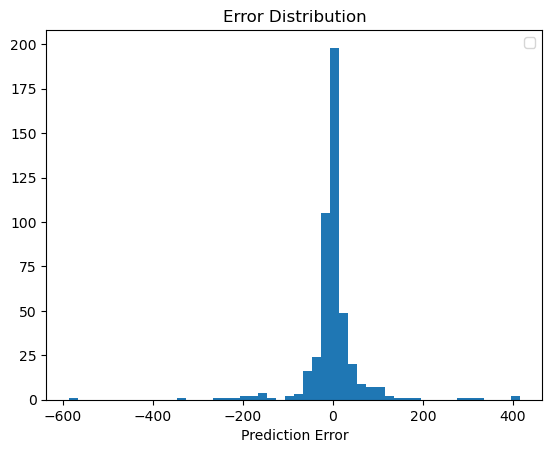

In [842]:
errors = np.abs(y_test - y_pred)

# Top 10 worst predictions
worst_indices = np.argsort(errors)[-10:][::-1]

print("Idx | Actual | Predicted | Error")
print("-" * 40)
for i in worst_indices:
    print(f"{i:4d} | {y_test[i]:7.4f} | {y_pred[i]:9.4f} | {errors[i]:.4f}")

# Error distribution plot
plt.hist(y_test - y_pred, bins=50)
plt.xlabel('Prediction Error')
plt.title('Error Distribution')
plt.legend()
plt.show()

### Feature Importance

In [843]:
zipped = zip(attributes, dt_reg_DEE.feature_importances_)
zipped = sorted(zipped, key=lambda x: x[1], reverse=True)
for col, imp in zipped:
    print(col, imp)

BIA-BIA_TBW 0.5200925891110344
BIA-BIA_Activity_Level_num 0.31688017356355447
BIA-BIA_BMR 0.14590266263454288
Basic_Demos-Sex 0.012685756462773945
Physical-Height 0.0030222073548620675
Physical-Weight 0.0011371506319055274
BIA-BIA_Fat 0.00027946024132667954
Basic_Demos-Age 0.0


## TARGET VARIABLE BIA-BIA_BMC

In [844]:
df_BIA_BMC = df[[
'BIA-BIA_LST' ,
'BIA-BIA_ICW',
'BIA-BIA_BMR' ,
'BIA-BIA_BMC'
]]





In [845]:
df_BIA_BMC=df_BIA_BMC.dropna(subset=['BIA-BIA_BMR'])

In [846]:
df_BIA_BMC.isnull().sum()

BIA-BIA_LST    0
BIA-BIA_ICW    0
BIA-BIA_BMR    0
BIA-BIA_BMC    0
dtype: int64

### Partitioning

In [847]:
attributes = [col for col in df_BIA_BMC.columns if col != 'BIA-BIA_BMC']
X = df_BIA_BMC[attributes].values
y = np.array(df_BIA_BMC['BIA-BIA_BMC'])

In [848]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)


In [849]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(1392, 3) (464, 3) (1392,) (464,)


In [850]:
df_BIA_BMC.shape

(1856, 4)

### Randomized Search

In [851]:
# options for scoring
#scoring='neg_mean_squared_error'      # most common, minimizes large errors
#scoring='neg_mean_absolute_error'     # more robust to outliers
#scoring='neg_root_mean_squared_error' # directly in target units
#scoring='r2'                          # maximizes explained variance

In [852]:
param_list = {
    'max_depth': [None] + list(np.arange(2, 50)),
    'min_samples_split': [0.001, 0.002, 0.01, 0.05, 0.1, 0.2],
    'min_samples_leaf': [5, 10, 20, 30, 50, 100, 150],
    'criterion': ['squared_error', 'absolute_error', 'friedman_mse']  
}

dt_reg_BMC = DecisionTreeRegressor()  

random_search = RandomizedSearchCV(
    DecisionTreeRegressor(),    
    param_distributions=param_list,
    cv=KFold(n_splits=5, shuffle=True, random_state=0), 
    scoring='neg_mean_squared_error' ,   
    n_jobs=-1,
    refit=True,
    n_iter=300,
)

random_search.fit(X_train, y_train)
dt_reg_BMC = random_search.best_estimator_

In [853]:
print(random_search.best_params_, random_search.best_score_)

{'min_samples_split': 0.001, 'min_samples_leaf': 5, 'max_depth': 45, 'criterion': 'squared_error'} -2.097283650186616


In [854]:
dt_reg_BMC = random_search.best_estimator_
dt_reg_BMC.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=45, min_samples_leaf=5, min_samples_split=0.001)

In [855]:
y_pred = dt_reg_BMC.predict(X_test)

print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}") # Typical error
print(f"MAE  : {mean_absolute_error(y_test, y_pred):.4f}")  #Average Error
print(f"MSE  : {mean_squared_error(y_test, y_pred):.4f}")  #Average Error
print(f"R²   : {r2_score(y_test, y_pred):.4f}") # variance in the target variable

RMSE : 1.2927
MAE  : 0.6553
MSE  : 1.6712
R²   : 0.7273


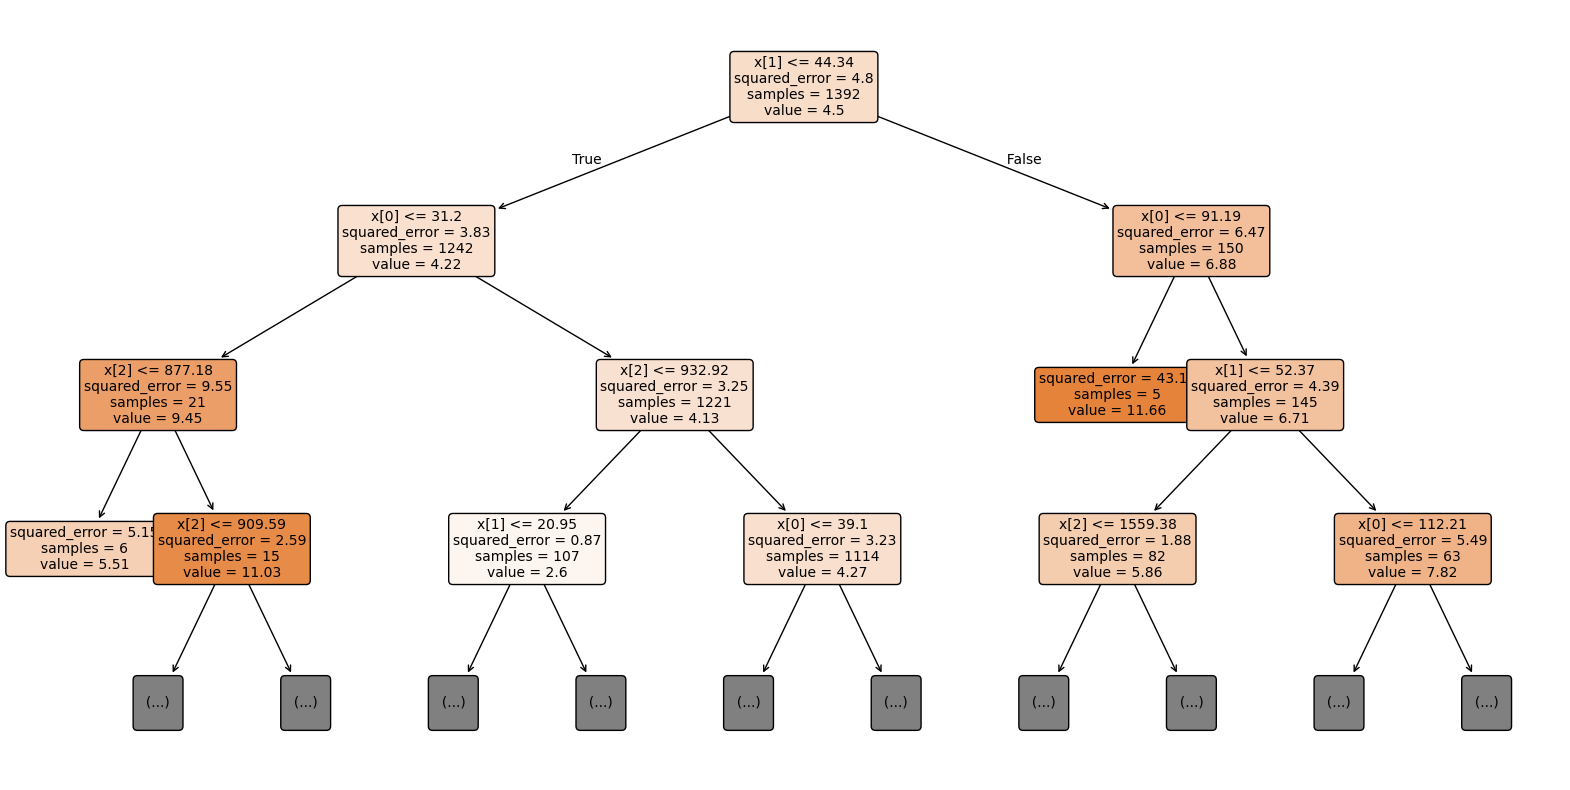

In [856]:
plt.figure(figsize=(20, 10))

plot_tree(
    dt_reg_BMC,
    filled=True,
    rounded=True,
    fontsize=10,
    precision=2,
    max_depth = 3
)

plt.show()

Idx | Actual | Predicted | Error
----------------------------------------
  41 | 22.4353 |   11.7870 | 10.6483
 423 | 15.1353 |    5.3246 | 9.8107
 246 |  0.4167 |    6.6924 | 6.2756
 382 | 17.5715 |   11.7870 | 5.7845
 311 |  2.3325 |    8.0767 | 5.7443
 200 | 16.3969 |   10.8039 | 5.5930
 348 |  9.1154 |    4.8841 | 4.2313
 357 |  7.4504 |   11.6640 | 4.2136
 115 | 11.7784 |    7.5848 | 4.1936
 134 |  0.5630 |    4.7234 | 4.1605


C:\Users\paula\AppData\Local\Temp\ipykernel_11332\1016786874.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


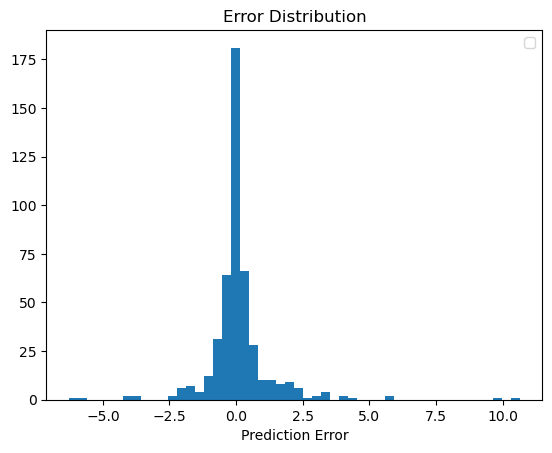

In [857]:
errors = np.abs(y_test - y_pred)

# Top 10 worst predictions
worst_indices = np.argsort(errors)[-10:][::-1]

print("Idx | Actual | Predicted | Error")
print("-" * 40)
for i in worst_indices:
    print(f"{i:4d} | {y_test[i]:7.4f} | {y_pred[i]:9.4f} | {errors[i]:.4f}")

# Error distribution plot
plt.hist(y_test - y_pred, bins=50)
plt.xlabel('Prediction Error')
plt.title('Error Distribution')
plt.legend()
plt.show()

### Feature Importance

In [858]:
zipped = zip(attributes, dt_reg_BMC.feature_importances_)
zipped = sorted(zipped, key=lambda x: x[1], reverse=True)
for col, imp in zipped:
    print(col, imp)

BIA-BIA_LST 0.473749162407294
BIA-BIA_BMR 0.27649105853758943
BIA-BIA_ICW 0.24975977905511668


## TARGET VARIABLE BIA-BIA_SMM

In [859]:
df_BIA_SMM = df[[
'BIA-BIA_LST',
'BIA-BIA_ICW',
'BIA-BIA_FFM',
'BIA-BIA_SMM'
]]






In [860]:
df_BIA_SMM=df_BIA_SMM.dropna()

In [861]:
df_BIA_SMM.isnull().sum()

BIA-BIA_LST    0
BIA-BIA_ICW    0
BIA-BIA_FFM    0
BIA-BIA_SMM    0
dtype: int64

### Partitioning

In [862]:
attributes = [col for col in df_BIA_SMM.columns if col != 'BIA-BIA_SMM']
X = df_BIA_SMM[attributes].values
y = np.array(df_BIA_SMM['BIA-BIA_SMM'])

In [863]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)


In [864]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(1392, 3) (465, 3) (1392,) (465,)


In [865]:
df_BIA_SMM.shape

(1857, 4)

### Randomized Search

In [866]:
# options for scoring
#scoring='neg_mean_squared_error'      # most common, minimizes large errors
#scoring='neg_mean_absolute_error'     # more robust to outliers
#scoring='neg_root_mean_squared_error' # directly in target units
#scoring='r2'                          # maximizes explained variance

In [867]:
param_list = {
    'max_depth': [None] + list(np.arange(2, 50)),
    'min_samples_split': [0.001, 0.002, 0.01, 0.05, 0.1, 0.2],
    'min_samples_leaf': [5, 10, 20, 30, 50, 100, 150],
    'criterion': ['squared_error', 'absolute_error', 'friedman_mse']  
}

dt_reg_SMM = DecisionTreeRegressor()  

random_search = RandomizedSearchCV(
    DecisionTreeRegressor(),    
    param_distributions=param_list,
    cv=KFold(n_splits=5, shuffle=True, random_state=0), 
    scoring='neg_mean_squared_error' ,   
    n_jobs=-1,
    refit=True,
    n_iter=300,
)

random_search.fit(X_train, y_train)
dt_reg_SMM = random_search.best_estimator_

In [868]:
print(random_search.best_params_, random_search.best_score_)

{'min_samples_split': 0.001, 'min_samples_leaf': 5, 'max_depth': 8, 'criterion': 'absolute_error'} -18.34448691219827


In [869]:
dt_reg_SMM = random_search.best_estimator_
dt_reg_SMM.fit(X_train, y_train)

DecisionTreeRegressor(criterion='absolute_error', max_depth=8,
                      min_samples_leaf=5, min_samples_split=0.001)

In [870]:
y_pred = dt_reg_SMM.predict(X_test)

print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}") # Typical error
print(f"MAE  : {mean_absolute_error(y_test, y_pred):.4f}")  #Average Error
print(f"MSE  : {mean_squared_error(y_test, y_pred):.4f}")  #Average Error
print(f"R²   : {r2_score(y_test, y_pred):.4f}") # variance in the target variable

RMSE : 3.8895
MAE  : 2.3533
MSE  : 15.1285
R²   : 0.9125


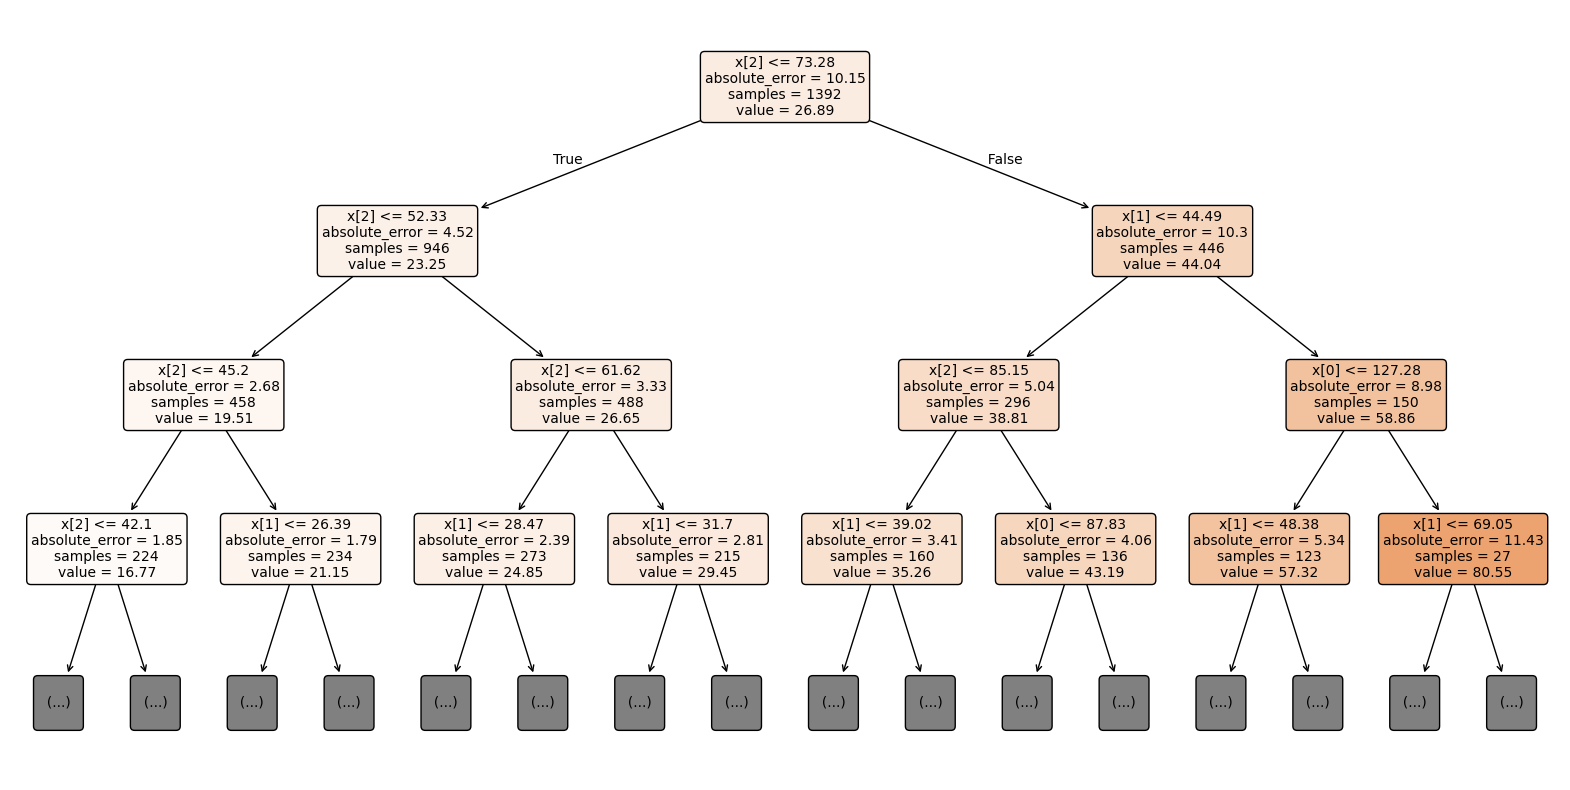

In [871]:
plt.figure(figsize=(20, 10))

plot_tree(
    dt_reg_SMM,
    filled=True,
    rounded=True,
    fontsize=10,
    precision=2,
    max_depth = 3
)

plt.show()

Idx | Actual | Predicted | Error
----------------------------------------
  24 | 80.7192 |  105.7740 | 25.0548
 252 | 89.3602 |   69.8678 | 19.4925
 366 | 87.8876 |  105.7740 | 17.8864
  98 | 44.8130 |   28.2149 | 16.5981
 257 | 45.9670 |   61.5239 | 15.5569
 166 | 50.5667 |   35.9874 | 14.5793
 418 | 34.7367 |   21.1244 | 13.6123
  95 | 46.0271 |   32.5252 | 13.5019
  41 | 32.6623 |   20.8134 | 11.8489
 118 | 31.8455 |   20.8134 | 11.0321


C:\Users\paula\AppData\Local\Temp\ipykernel_11332\1016786874.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


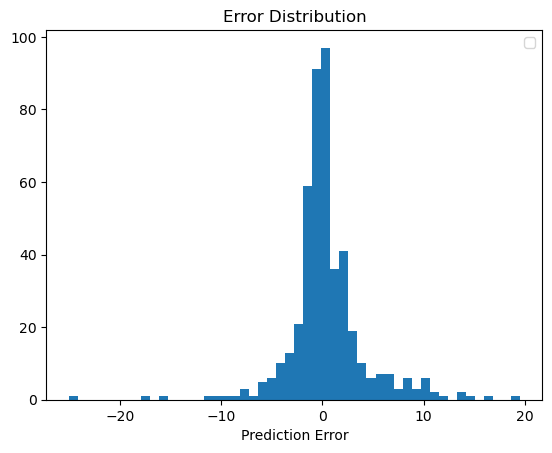

In [872]:
errors = np.abs(y_test - y_pred)

# Top 10 worst predictions
worst_indices = np.argsort(errors)[-10:][::-1]

print("Idx | Actual | Predicted | Error")
print("-" * 40)
for i in worst_indices:
    print(f"{i:4d} | {y_test[i]:7.4f} | {y_pred[i]:9.4f} | {errors[i]:.4f}")

# Error distribution plot
plt.hist(y_test - y_pred, bins=50)
plt.xlabel('Prediction Error')
plt.title('Error Distribution')
plt.legend()
plt.show()

### Feature Importance

In [873]:
zipped = zip(attributes, dt_reg_SMM.feature_importances_)
zipped = sorted(zipped, key=lambda x: x[1], reverse=True)
for col, imp in zipped:
    print(col, imp)

BIA-BIA_FFM 0.6984304221547409
BIA-BIA_ICW 0.2398668474897509
BIA-BIA_LST 0.06170273035550811


## TARGET VARIABLE BIA-BIA_Activity_Level_num

In [874]:
df_BIA_ACT_LEV= df[[
'BIA-BIA_DEE',
'BIA-BIA_FFM',
'BIA-BIA_LST',
'Physical-Weight',
'BIA-BIA_ICW',
'BIA-BIA_TBW',
'BIA-BIA_Activity_Level_num'
]]

In [875]:
df_BIA_ACT_LEV=df_BIA_ACT_LEV.dropna()

In [876]:
df_BIA_ACT_LEV.isnull().sum()

BIA-BIA_DEE                   0
BIA-BIA_FFM                   0
BIA-BIA_LST                   0
Physical-Weight               0
BIA-BIA_ICW                   0
BIA-BIA_TBW                   0
BIA-BIA_Activity_Level_num    0
dtype: int64

### Partitioning

In [877]:
attributes = [col for col in df_BIA_ACT_LEV.columns if col != 'BIA-BIA_Activity_Level_num']
X = df_BIA_ACT_LEV[attributes].values
y = np.array(df_BIA_ACT_LEV['BIA-BIA_Activity_Level_num'])

In [878]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)


In [879]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(1392, 6) (464, 6) (1392,) (464,)


In [880]:
df_BIA_ACT_LEV.shape

(1856, 7)

### Randomized Search

In [881]:
# options for scoring
#scoring='neg_mean_squared_error'      # most common, minimizes large errors
#scoring='neg_mean_absolute_error'     # more robust to outliers
#scoring='neg_root_mean_squared_error' # directly in target units
#scoring='r2'                          # maximizes explained variance

In [882]:
param_list = {
    'max_depth': [None] + list(np.arange(2, 50)),
    'min_samples_split': [0.001, 0.002, 0.01, 0.05, 0.1, 0.2],
    'min_samples_leaf': [5, 10, 20, 30, 50, 100, 150],
    'criterion': ['squared_error', 'absolute_error', 'friedman_mse']  
}

dt_reg_ACT_LEV = DecisionTreeRegressor()  

random_search = RandomizedSearchCV(
    DecisionTreeRegressor(),    
    param_distributions=param_list,
    cv=KFold(n_splits=5, shuffle=True, random_state=0), 
    scoring='neg_mean_squared_error' ,   
    n_jobs=-1,
    refit=True,
    n_iter=300,
)

random_search.fit(X_train, y_train)
dt_reg_ACT_LEV = random_search.best_estimator_

In [883]:
print(random_search.best_params_, random_search.best_score_)

{'min_samples_split': 0.002, 'min_samples_leaf': 5, 'max_depth': 48, 'criterion': 'friedman_mse'} -0.13858661630176997


In [884]:
dt_reg_ACT_LEV = random_search.best_estimator_
dt_reg_ACT_LEV.fit(X_train, y_train)

DecisionTreeRegressor(criterion='friedman_mse', max_depth=48,
                      min_samples_leaf=5, min_samples_split=0.002)

In [885]:
y_pred = dt_reg_ACT_LEV.predict(X_test)

print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}") # Typical error
print(f"MAE  : {mean_absolute_error(y_test, y_pred):.4f}")  #Average Error
print(f"MSE  : {mean_squared_error(y_test, y_pred):.4f}")  #Average Error
print(f"R²   : {r2_score(y_test, y_pred):.4f}") # variance in the target variable

RMSE : 0.3769
MAE  : 0.1793
MSE  : 0.1421
R²   : 0.8625


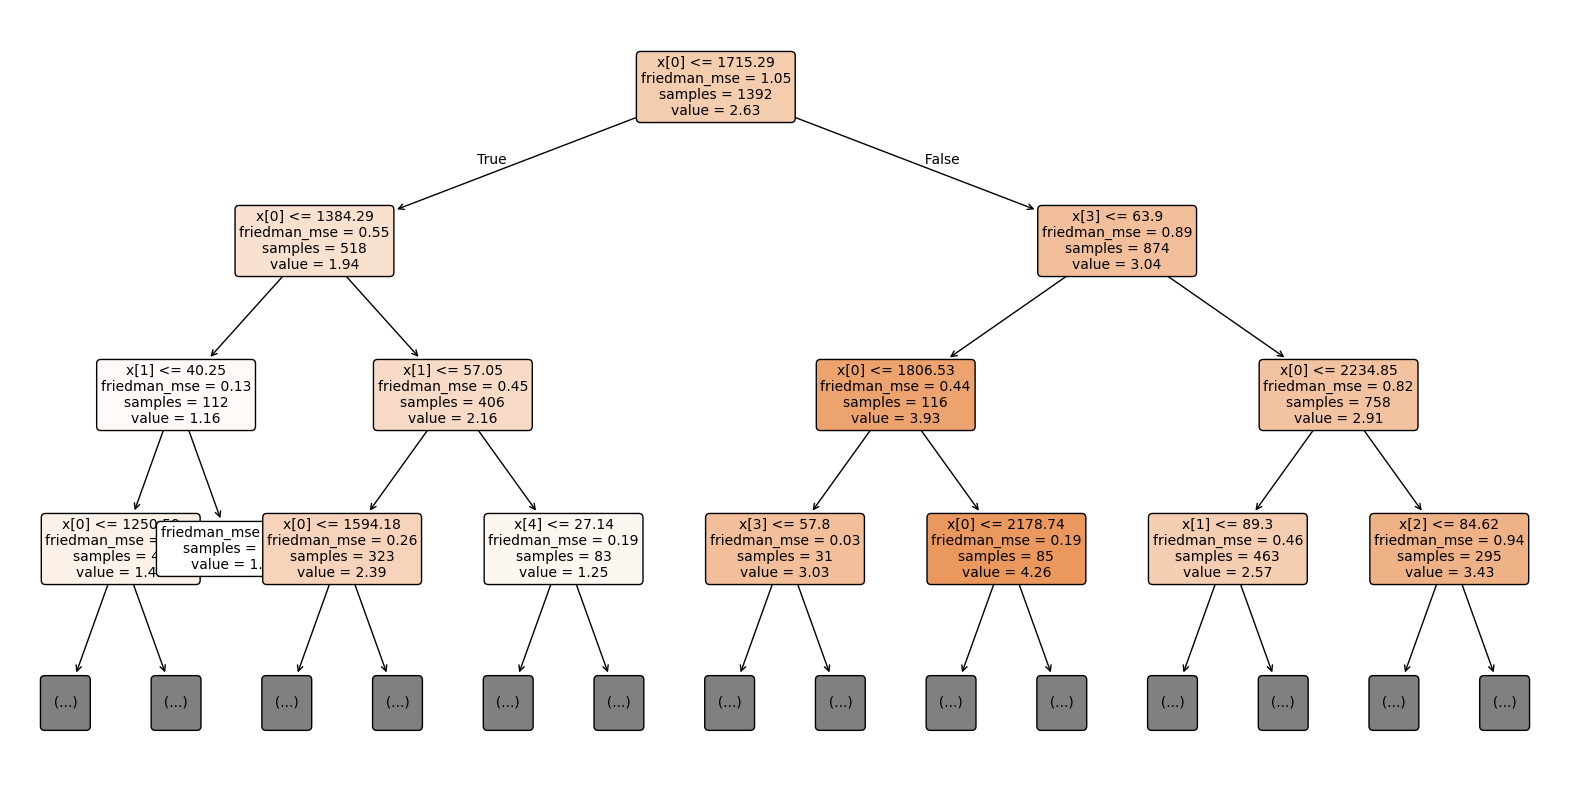

In [886]:
plt.figure(figsize=(20, 10))

plot_tree(
    dt_reg_ACT_LEV,
    filled=True,
    rounded=True,
    fontsize=10,
    precision=2,
    max_depth = 3
)

plt.show()

Idx | Actual | Predicted | Error
----------------------------------------
 140 |  5.0000 |    3.5000 | 1.5000
 444 |  2.0000 |    3.5000 | 1.5000
 463 |  2.0000 |    3.0000 | 1.0000
 309 |  2.0000 |    3.0000 | 1.0000
 215 |  2.0000 |    3.0000 | 1.0000
 234 |  2.0000 |    1.0000 | 1.0000
 241 |  3.0000 |    2.0000 | 1.0000
 246 |  2.0000 |    3.0000 | 1.0000
 283 |  3.0000 |    2.0000 | 1.0000
 289 |  2.0000 |    3.0000 | 1.0000


C:\Users\paula\AppData\Local\Temp\ipykernel_11332\1016786874.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


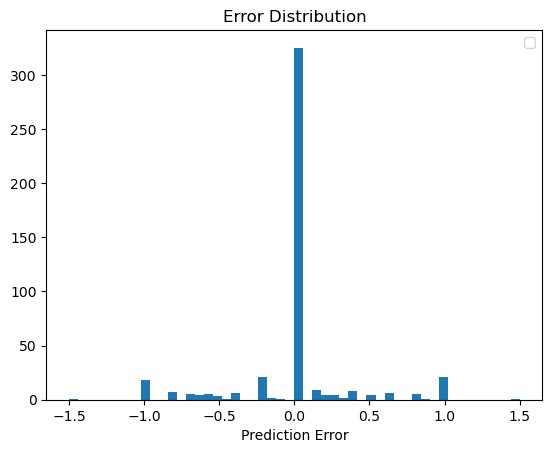

In [887]:
errors = np.abs(y_test - y_pred)

# Top 10 worst predictions
worst_indices = np.argsort(errors)[-10:][::-1]

print("Idx | Actual | Predicted | Error")
print("-" * 40)
for i in worst_indices:
    print(f"{i:4d} | {y_test[i]:7.4f} | {y_pred[i]:9.4f} | {errors[i]:.4f}")

# Error distribution plot
plt.hist(y_test - y_pred, bins=50)
plt.xlabel('Prediction Error')
plt.title('Error Distribution')
plt.legend()
plt.show()

### Feature Importance

In [888]:
zipped = zip(attributes, dt_reg_ACT_LEV.feature_importances_)
zipped = sorted(zipped, key=lambda x: x[1], reverse=True)
for col, imp in zipped:
    print(col, imp)

BIA-BIA_DEE 0.6000515129536189
BIA-BIA_FFM 0.14542683292614839
Physical-Weight 0.0947956262158819
BIA-BIA_LST 0.07910532586980724
BIA-BIA_ICW 0.050122608278486074
BIA-BIA_TBW 0.030498093756057592


## TARGET VARIABLE BIA-BIA_Frame_num

In [928]:
df_BIA_Frame= df[[
       'Physical-Height', 
       'Physical-Weight',
       'BIA-BIA_Fat' ,
       'BIA-BIA_Frame_num'
]]

In [929]:
df_BIA_Frame=df_BIA_Frame.dropna()

In [930]:
df_BIA_Frame.isnull().sum()

Physical-Height      0
Physical-Weight      0
BIA-BIA_Fat          0
BIA-BIA_Frame_num    0
dtype: int64

### Partitioning

In [931]:
attributes = [col for col in df_BIA_Frame.columns if col != 'BIA-BIA_Frame_num']
X = df_BIA_Frame[attributes].values
y = np.array(df_BIA_Frame['BIA-BIA_Frame_num'])

In [932]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)


In [933]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(1392, 3) (464, 3) (1392,) (464,)


In [934]:
df_BIA_Frame.shape

(1856, 4)

### Randomized Search

In [935]:
# options for scoring
#scoring='neg_mean_squared_error'      # most common, minimizes large errors
#scoring='neg_mean_absolute_error'     # more robust to outliers
#scoring='neg_root_mean_squared_error' # directly in target units
#scoring='r2'                          # maximizes explained variance

In [936]:
param_list = {
    'max_depth': [None] + list(np.arange(2, 50)),
    'min_samples_split': [0.001, 0.002, 0.01, 0.05, 0.1, 0.2],
    'min_samples_leaf': [5, 10, 20, 30, 50, 100, 150],
    'criterion': ['squared_error', 'absolute_error', 'friedman_mse']  
}

dt_reg_Frame = DecisionTreeRegressor()  

random_search = RandomizedSearchCV(
    DecisionTreeRegressor(),    
    param_distributions=param_list,
    cv=KFold(n_splits=5, shuffle=True, random_state=0), 
    scoring='neg_mean_squared_error' ,   
    n_jobs=-1,
    refit=True,
    n_iter=300,
)

random_search.fit(X_train, y_train)
dt_reg_Frame = random_search.best_estimator_

In [937]:
print(random_search.best_params_, random_search.best_score_)

{'min_samples_split': 0.2, 'min_samples_leaf': 30, 'max_depth': 43, 'criterion': 'squared_error'} -0.2713047989007131


In [938]:
dt_reg_Frame = random_search.best_estimator_
dt_reg_Frame.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=43, min_samples_leaf=30, min_samples_split=0.2)

In [939]:
y_pred = dt_reg_Frame.predict(X_test)

print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}") # Typical error
print(f"MAE  : {mean_absolute_error(y_test, y_pred):.4f}")  #Average Error
print(f"MSE  : {mean_squared_error(y_test, y_pred):.4f}")  #Average Error
print(f"R²   : {r2_score(y_test, y_pred):.4f}") # variance in the target variable

RMSE : 0.5385
MAE  : 0.4362
MSE  : 0.2899
R²   : 0.3815


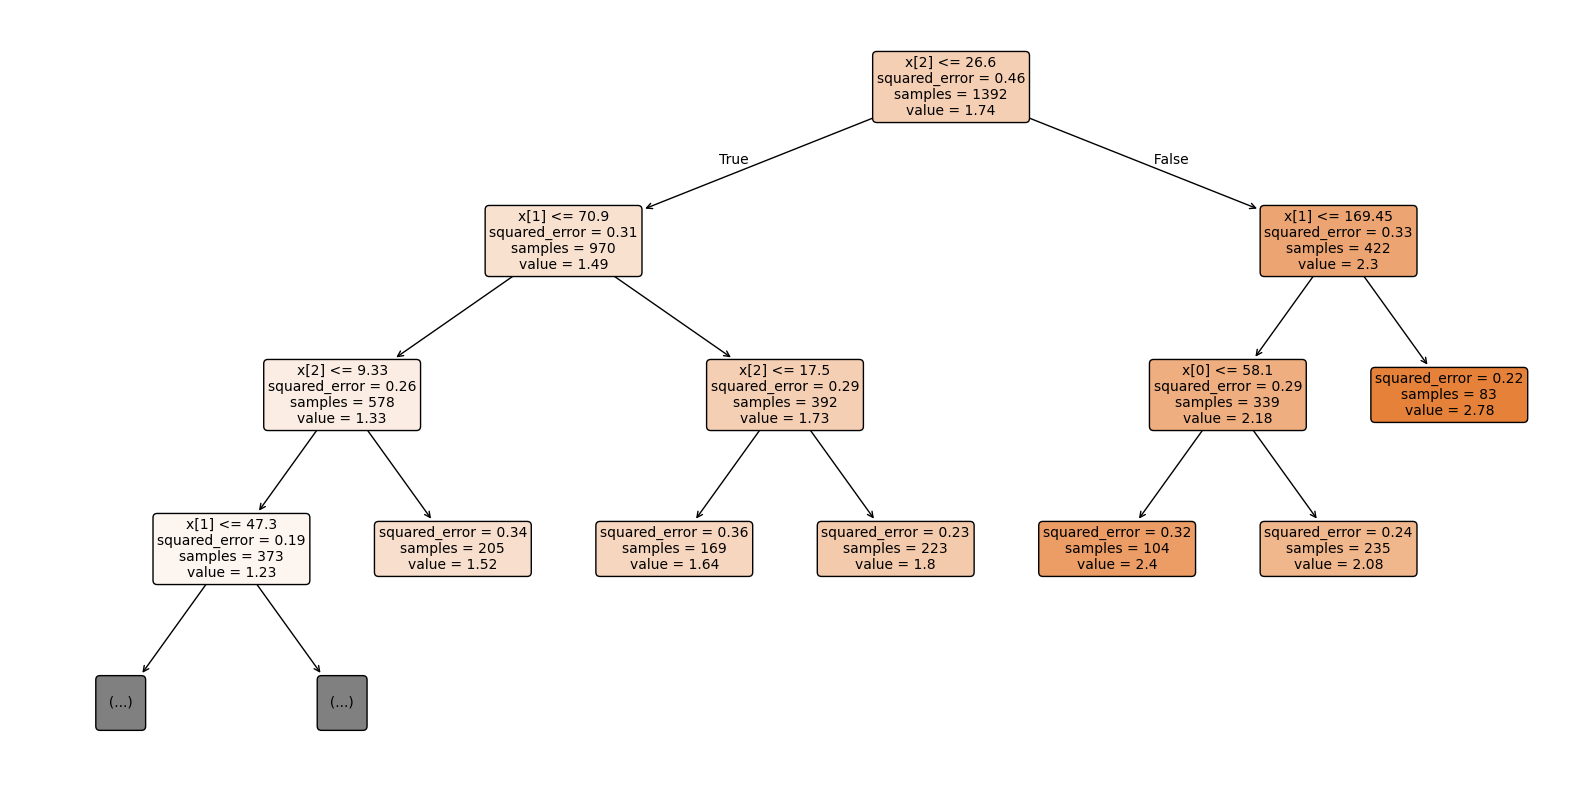

In [940]:
plt.figure(figsize=(20, 10))

plot_tree(
    dt_reg_Frame,
    filled=True,
    rounded=True,
    fontsize=10,
    precision=2,
    max_depth = 3
)

plt.show()

Idx | Actual | Predicted | Error
----------------------------------------
 413 |  3.0000 |    1.2840 | 1.7160
 301 |  3.0000 |    1.2840 | 1.7160
 177 |  3.0000 |    1.2840 | 1.7160
 273 |  3.0000 |    1.2840 | 1.7160
 316 |  3.0000 |    1.5220 | 1.4780
  15 |  3.0000 |    1.6391 | 1.3609
 323 |  3.0000 |    1.6391 | 1.3609
 410 |  3.0000 |    1.8027 | 1.1973
 308 |  3.0000 |    1.8027 | 1.1973
  12 |  3.0000 |    1.8027 | 1.1973


C:\Users\paula\AppData\Local\Temp\ipykernel_11332\1016786874.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


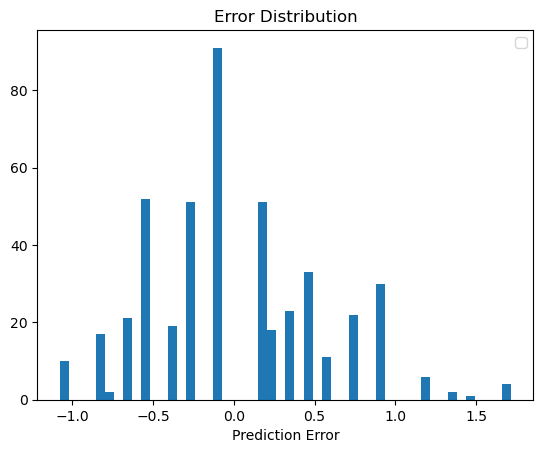

In [941]:
errors = np.abs(y_test - y_pred)

# Top 10 worst predictions
worst_indices = np.argsort(errors)[-10:][::-1]

print("Idx | Actual | Predicted | Error")
print("-" * 40)
for i in worst_indices:
    print(f"{i:4d} | {y_test[i]:7.4f} | {y_pred[i]:9.4f} | {errors[i]:.4f}")

# Error distribution plot
plt.hist(y_test - y_pred, bins=50)
plt.xlabel('Prediction Error')
plt.title('Error Distribution')
plt.legend()
plt.show()

### Feature Importance

In [942]:
zipped = zip(attributes, dt_reg_Frame.feature_importances_)
zipped = sorted(zipped, key=lambda x: x[1], reverse=True)
for col, imp in zipped:
    print(col, imp)

BIA-BIA_Fat 0.7371138358667564
Physical-Weight 0.2349942545470542
Physical-Height 0.02789190958618938


## TARGET VARIABLE Physical-HeartRate

In [1006]:
df_HeartRate = df[[
       'Physical-HeartRate', 
       'Physical-Height',
       'Physical-Weight',
       'Physical-MAP_CAL' 
       ]].copy()





In [1007]:
df_HeartRate=df_HeartRate.dropna()

In [1008]:
df_HeartRate.isnull().sum()

Physical-HeartRate    0
Physical-Height       0
Physical-Weight       0
Physical-MAP_CAL      0
dtype: int64

### Partitioning

In [1009]:
attributes = [col for col in df_HeartRate.columns if col != 'Physical-HeartRate']
X = df_HeartRate[attributes].values
y = np.array(df_HeartRate['Physical-HeartRate'])

In [1010]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)


In [1011]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(1389, 3) (464, 3) (1389,) (464,)


In [1012]:
df_HeartRate.shape

(1853, 4)

### Randomized Search

In [1013]:
# options for scoring
#scoring='neg_mean_squared_error'      # most common, minimizes large errors
#scoring='neg_mean_absolute_error'     # more robust to outliers
#scoring='neg_root_mean_squared_error' # directly in target units
#scoring='r2'                          # maximizes explained variance

In [1014]:
param_list = {
    'max_depth': [None] + list(np.arange(2, 50)),
    'min_samples_split': [0.001, 0.002, 0.01, 0.05, 0.1, 0.2],
    'min_samples_leaf': [5, 10, 20, 30, 50, 100, 150],
    'criterion': ['squared_error', 'absolute_error', 'friedman_mse']  
}

dt_reg_HeartRate = DecisionTreeRegressor()  

random_search = RandomizedSearchCV(
    DecisionTreeRegressor(),    
    param_distributions=param_list,
    cv=KFold(n_splits=5, shuffle=True, random_state=0), 
    scoring='neg_mean_squared_error' ,   
    n_jobs=-1,
    refit=True,
    n_iter=300,
)

random_search.fit(X_train, y_train)
dt_reg_HeartRate = random_search.best_estimator_

In [1015]:
print(random_search.best_params_, random_search.best_score_)

{'min_samples_split': 0.2, 'min_samples_leaf': 50, 'max_depth': 32, 'criterion': 'absolute_error'} -159.58658156507286


In [1016]:
dt_reg_HeartRate = random_search.best_estimator_
dt_reg_HeartRate.fit(X_train, y_train)

DecisionTreeRegressor(criterion='absolute_error', max_depth=32,
                      min_samples_leaf=50, min_samples_split=0.2)

In [1017]:
y_pred = dt_reg_HeartRate.predict(X_test)

print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}") # Typical error
print(f"MAE  : {mean_absolute_error(y_test, y_pred):.4f}")  #Average Error
print(f"MSE  : {mean_squared_error(y_test, y_pred):.4f}")  #Average Error
print(f"R²   : {r2_score(y_test, y_pred):.4f}") # variance in the target variable

RMSE : 12.9506
MAE  : 10.6519
MSE  : 167.7193
R²   : -0.0140


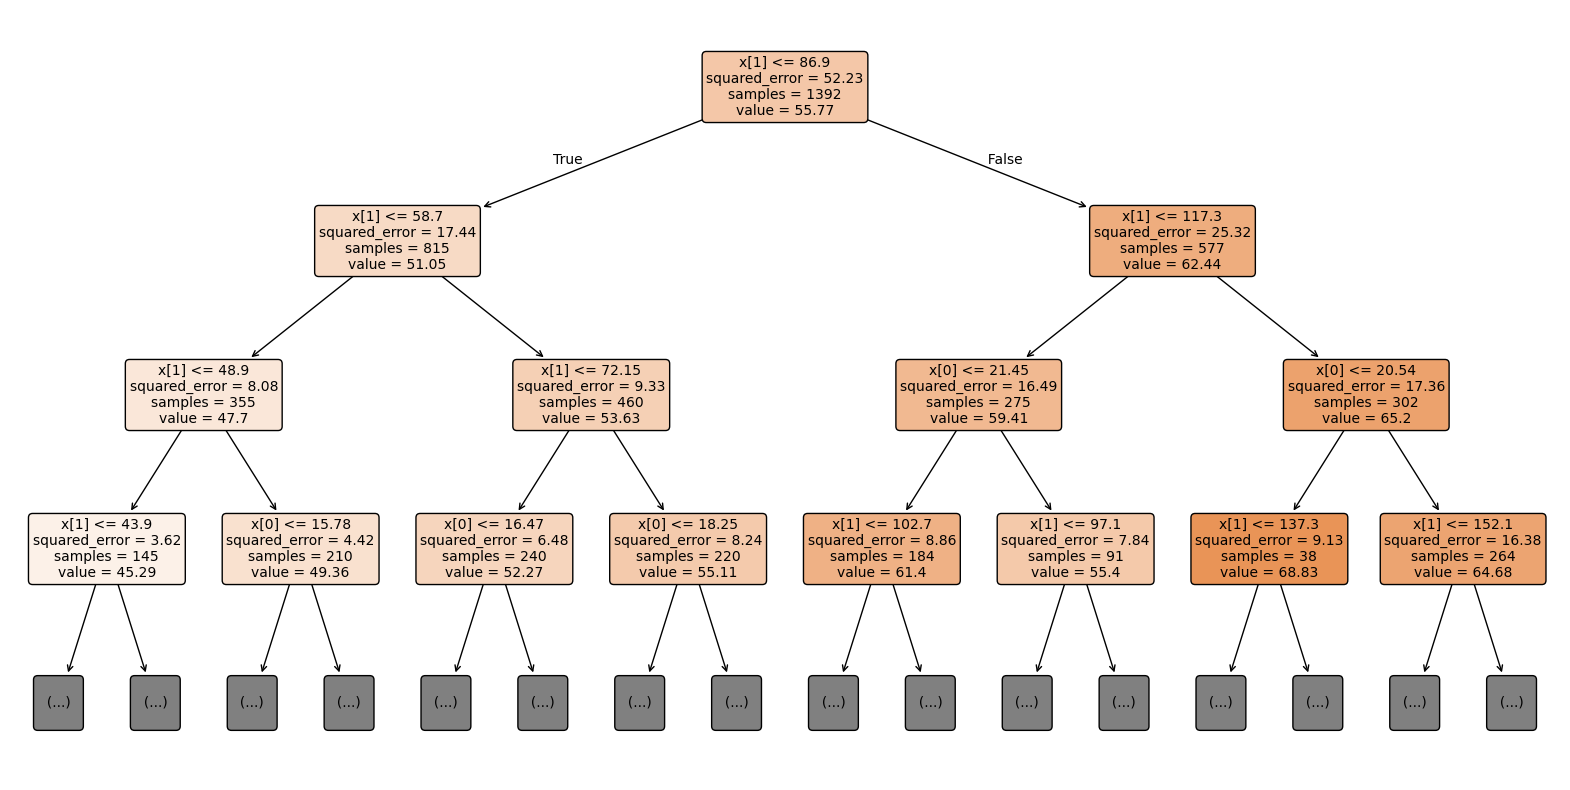

In [1018]:
plt.figure(figsize=(20, 10))

plot_tree(
    dt_reg_height,
    filled=True,
    rounded=True,
    fontsize=10,
    precision=2,
    max_depth = 3
)

plt.show()

Idx | Actual | Predicted | Error
----------------------------------------
 358 | 46.0000 |   91.0000 | 45.0000
 443 | 118.0000 |   78.0000 | 40.0000
 296 | 113.0000 |   78.0000 | 35.0000
  72 | 107.0000 |   73.0000 | 34.0000
 109 | 112.0000 |   78.0000 | 34.0000
 151 | 120.0000 |   87.5000 | 32.5000
 424 | 111.0000 |   82.0000 | 29.0000
 240 | 62.0000 |   91.0000 | 29.0000
 219 | 116.0000 |   87.5000 | 28.5000
 348 | 63.0000 |   91.0000 | 28.0000


C:\Users\paula\AppData\Local\Temp\ipykernel_11332\1016786874.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


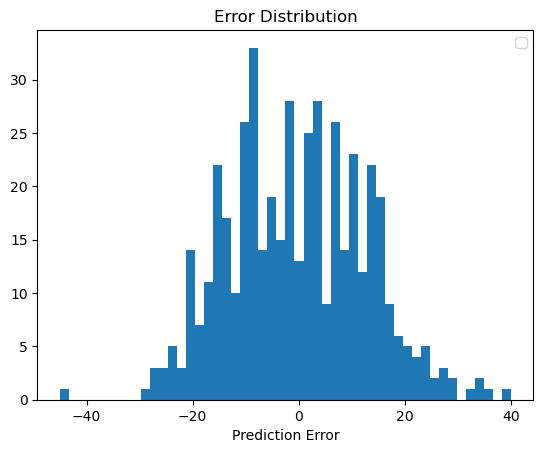

In [1019]:
errors = np.abs(y_test - y_pred)

# Top 10 worst predictions
worst_indices = np.argsort(errors)[-10:][::-1]

print("Idx | Actual | Predicted | Error")
print("-" * 40)
for i in worst_indices:
    print(f"{i:4d} | {y_test[i]:7.4f} | {y_pred[i]:9.4f} | {errors[i]:.4f}")

# Error distribution plot
plt.hist(y_test - y_pred, bins=50)
plt.xlabel('Prediction Error')
plt.title('Error Distribution')
plt.legend()
plt.show()

### Feature Importance

In [1020]:
zipped = zip(attributes, dt_reg_HeartRate.feature_importances_)
zipped = sorted(zipped, key=lambda x: x[1], reverse=True)
for col, imp in zipped:
    print(col, imp)

Physical-Height 0.5092667203867849
Physical-MAP_CAL 0.4907332796132152
Physical-Weight 0.0


## TARGET VARIABLE CGAS-CGAS_Score'

In [1036]:
df_CGAS_Score = df[[
'CGAS-CGAS_Score', 
'SDS-SDS_Total_T',
'Physical-BMI',
'FGC-FGC_CORE_CAL',
'Basic_Demos-Age',
'Basic_Demos-Sex',
'Physical-Height',
'Physical-Weight'      
       ]].copy()





In [1037]:
df_CGAS_Score=df_CGAS_Score.dropna()

In [1038]:
df_CGAS_Score.isnull().sum()

CGAS-CGAS_Score     0
SDS-SDS_Total_T     0
Physical-BMI        0
FGC-FGC_CORE_CAL    0
Basic_Demos-Age     0
Basic_Demos-Sex     0
Physical-Height     0
Physical-Weight     0
dtype: int64

### Partitioning

In [1039]:
attributes = [col for col in df_CGAS_Score.columns if col != 'CGAS-CGAS_Score']
X = df_CGAS_Score[attributes].values
y = np.array(df_CGAS_Score['CGAS-CGAS_Score'])

In [1040]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)


In [1041]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(1114, 7) (372, 7) (1114,) (372,)


In [1042]:
df_CGAS_Score.shape

(1486, 8)

### Randomized Search

In [1043]:
# options for scoring
#scoring='neg_mean_squared_error'      # most common, minimizes large errors
#scoring='neg_mean_absolute_error'     # more robust to outliers
#scoring='neg_root_mean_squared_error' # directly in target units
#scoring='r2'                          # maximizes explained variance

In [1044]:
param_list = {
    'max_depth': [None] + list(np.arange(2, 50)),
    'min_samples_split': [0.001, 0.002, 0.01, 0.05, 0.1, 0.2],
    'min_samples_leaf': [5, 10, 20, 30, 50, 100, 150],
    'criterion': ['squared_error', 'absolute_error', 'friedman_mse']  
}

dt_reg_CGAS_Score = DecisionTreeRegressor()  

random_search = RandomizedSearchCV(
    DecisionTreeRegressor(),    
    param_distributions=param_list,
    cv=KFold(n_splits=5, shuffle=True, random_state=0), 
    scoring='neg_mean_squared_error' ,   
    n_jobs=-1,
    refit=True,
    n_iter=300,
)

random_search.fit(X_train, y_train)
dt_reg_CGAS_Score = random_search.best_estimator_

In [1045]:
print(random_search.best_params_, random_search.best_score_)

{'min_samples_split': 0.2, 'min_samples_leaf': 100, 'max_depth': 11, 'criterion': 'friedman_mse'} -123.9360059340328


In [1046]:
dt_reg_CGAS_Score = random_search.best_estimator_
dt_reg_CGAS_Score.fit(X_train, y_train)

DecisionTreeRegressor(criterion='friedman_mse', max_depth=11,
                      min_samples_leaf=100, min_samples_split=0.2)

In [1047]:
y_pred = dt_reg_CGAS_Score.predict(X_test)

print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}") # Typical error
print(f"MAE  : {mean_absolute_error(y_test, y_pred):.4f}")  #Average Error
print(f"MSE  : {mean_squared_error(y_test, y_pred):.4f}")  #Average Error
print(f"R²   : {r2_score(y_test, y_pred):.4f}") # variance in the target variable

RMSE : 11.1831
MAE  : 9.0834
MSE  : 125.0614
R²   : -0.0015


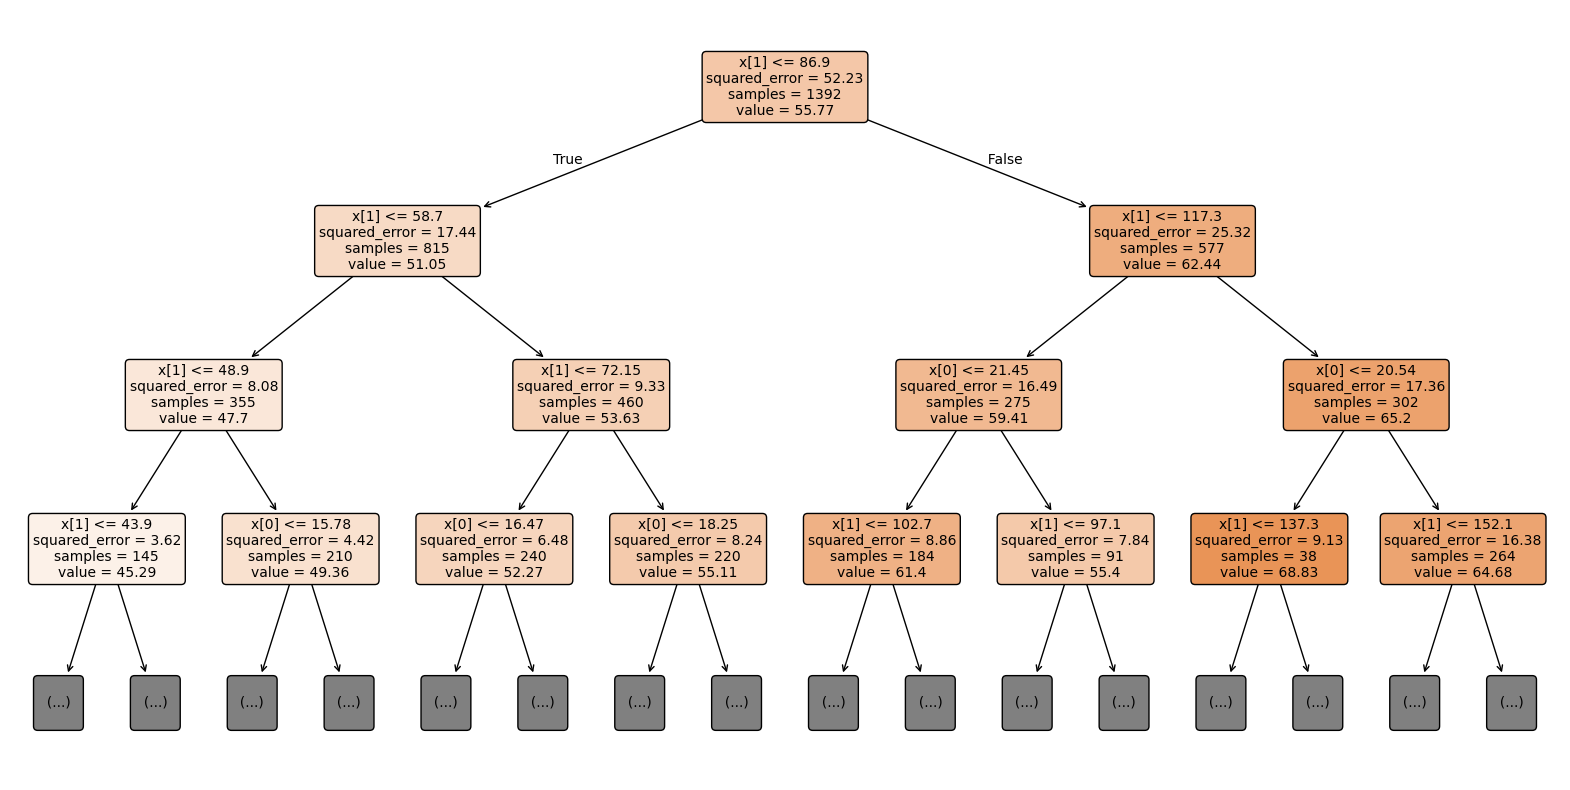

In [1048]:
plt.figure(figsize=(20, 10))

plot_tree(
    dt_reg_height,
    filled=True,
    rounded=True,
    fontsize=10,
    precision=2,
    max_depth = 3
)

plt.show()

Idx | Actual | Predicted | Error
----------------------------------------
  98 | 39.0000 |   69.9022 | 30.9022
 345 | 40.0000 |   67.8304 | 27.8304
 162 | 41.0000 |   67.2373 | 26.2373
 117 | 41.0000 |   67.2373 | 26.2373
 301 | 90.0000 |   64.0580 | 25.9420
 125 | 45.0000 |   69.9022 | 24.9022
 250 | 92.0000 |   67.8304 | 24.1696
 273 | 41.0000 |   65.0505 | 24.0505
 118 | 41.0000 |   65.0505 | 24.0505
 220 | 91.0000 |   67.8304 | 23.1696


C:\Users\paula\AppData\Local\Temp\ipykernel_11332\1016786874.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


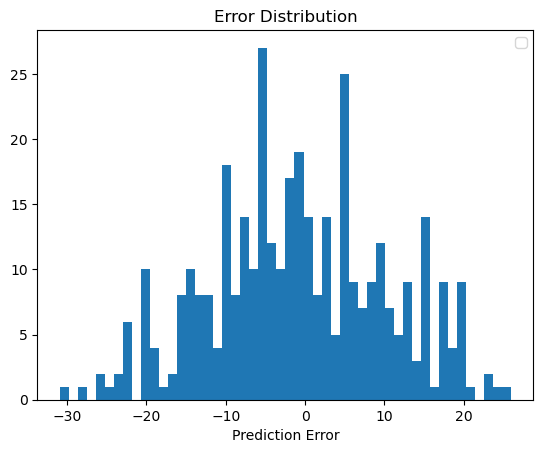

In [1049]:
errors = np.abs(y_test - y_pred)

# Top 10 worst predictions
worst_indices = np.argsort(errors)[-10:][::-1]

print("Idx | Actual | Predicted | Error")
print("-" * 40)
for i in worst_indices:
    print(f"{i:4d} | {y_test[i]:7.4f} | {y_pred[i]:9.4f} | {errors[i]:.4f}")

# Error distribution plot
plt.hist(y_test - y_pred, bins=50)
plt.xlabel('Prediction Error')
plt.title('Error Distribution')
plt.legend()
plt.show()

### Feature Importance

In [1050]:
zipped = zip(attributes, dt_reg_CGAS_Score.feature_importances_)
zipped = sorted(zipped, key=lambda x: x[1], reverse=True)
for col, imp in zipped:
    print(col, imp)

SDS-SDS_Total_T 0.4056260190369065
FGC-FGC_CORE_CAL 0.34119502619991443
Physical-Weight 0.1958871106655451
Physical-BMI 0.05729184409763396
Basic_Demos-Age 0.0
Basic_Demos-Sex 0.0
Physical-Height 0.0


## TARGET VARIABLE Fitness_Endurance-Max_Stage

In [1121]:
df_Fitness_Endurance= df[[
'Physical-Weight',
'FGC-FGC_CORE_CAL',
'CGAS-CGAS_Score',
'BIA-BIA_FFMI',
'Fitness_Endurance-Max_Stage' 
]]



In [1122]:
df_Fitness_Endurance=df_Fitness_Endurance.dropna()

In [1123]:
df_Fitness_Endurance.isnull().sum()

Physical-Weight                0
FGC-FGC_CORE_CAL               0
CGAS-CGAS_Score                0
BIA-BIA_FFMI                   0
Fitness_Endurance-Max_Stage    0
dtype: int64

### Partitioning

In [1124]:
attributes = [col for col in df_Fitness_Endurance.columns if col != 'Fitness_Endurance-Max_Stage']
X = df_Fitness_Endurance[attributes].values
y = np.array(df_Fitness_Endurance['Fitness_Endurance-Max_Stage'])

In [1125]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)


In [1126]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(834, 4) (278, 4) (834,) (278,)


In [1127]:
df_Fitness_Endurance.shape

(1112, 5)

### Randomized Search

In [1128]:
# options for scoring
#scoring='neg_mean_squared_error'      # most common, minimizes large errors
#scoring='neg_mean_absolute_error'     # more robust to outliers
#scoring='neg_root_mean_squared_error' # directly in target units
#scoring='r2'                          # maximizes explained variance

In [1129]:
param_list = {
    'max_depth': [None] + list(np.arange(2, 50)),
    'min_samples_split': [0.001, 0.002, 0.01, 0.05, 0.1, 0.2],
    'min_samples_leaf': [5, 10, 20, 30, 50, 100, 150],
    'criterion': ['squared_error', 'absolute_error', 'friedman_mse']  
}

dt_reg_Fitness_Endurance = DecisionTreeRegressor()  

random_search = RandomizedSearchCV(
    DecisionTreeRegressor(),    
    param_distributions=param_list,
    cv=KFold(n_splits=5, shuffle=True, random_state=0), 
    scoring='neg_mean_squared_error' ,   
    n_jobs=-1,
    refit=True,
    n_iter=300,
)

random_search.fit(X_train, y_train)
dt_reg_Fitness_Endurance = random_search.best_estimator_

In [1130]:
print(random_search.best_params_, random_search.best_score_)

{'min_samples_split': 0.001, 'min_samples_leaf': 20, 'max_depth': 2, 'criterion': 'friedman_mse'} -2.281901151544958


In [1131]:
dt_reg_Fitness_Endurance = random_search.best_estimator_
dt_reg_Fitness_Endurance.fit(X_train, y_train)

DecisionTreeRegressor(criterion='friedman_mse', max_depth=2,
                      min_samples_leaf=20, min_samples_split=0.001)

In [1132]:
y_pred = dt_reg_Fitness_Endurance.predict(X_test)

print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}") # Typical error
print(f"MAE  : {mean_absolute_error(y_test, y_pred):.4f}")  #Average Error
print(f"MSE  : {mean_squared_error(y_test, y_pred):.4f}")  #Average Error
print(f"R²   : {r2_score(y_test, y_pred):.4f}") # variance in the target variable

RMSE : 1.1386
MAE  : 0.7345
MSE  : 1.2964
R²   : 0.0711


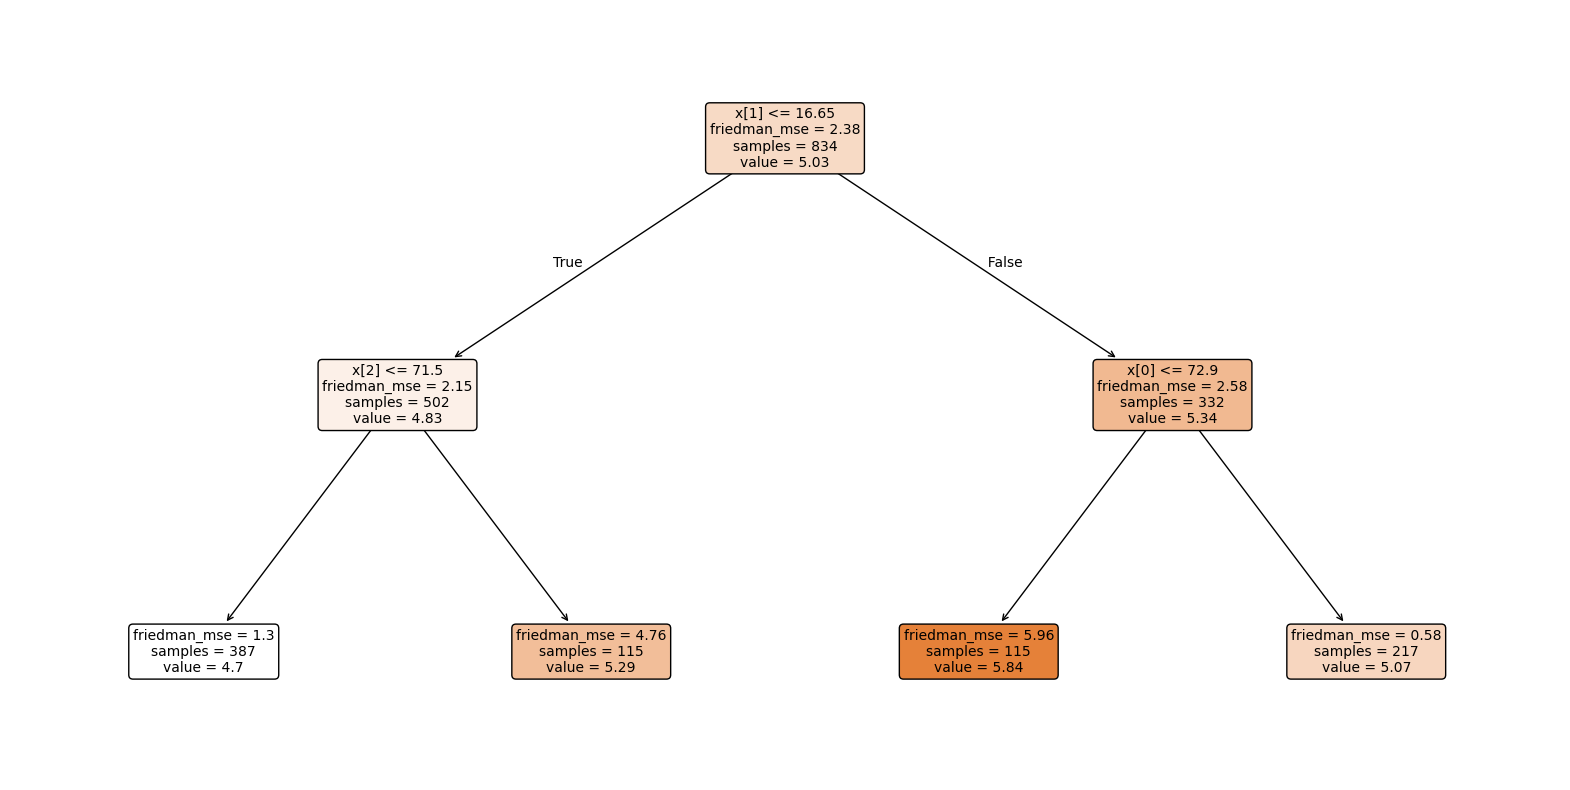

In [1133]:
plt.figure(figsize=(20, 10))

plot_tree(
    dt_reg_Fitness_Endurance,
    filled=True,
    rounded=True,
    fontsize=10,
    precision=2,
    max_depth = 3
)

plt.show()

Idx | Actual | Predicted | Error
----------------------------------------
 183 | 10.0000 |    5.0691 | 4.9309
 250 |  1.0000 |    5.8435 | 4.8435
  91 | 10.0000 |    5.8435 | 4.1565
 259 |  2.0000 |    5.8435 | 3.8435
  49 |  1.0000 |    4.7003 | 3.7003
 232 |  9.0000 |    5.8435 | 3.1565
  92 |  8.0000 |    5.0691 | 2.9309
  65 |  2.0000 |    4.7003 | 2.7003
 120 |  2.0000 |    4.7003 | 2.7003
  27 |  2.0000 |    4.7003 | 2.7003


C:\Users\paula\AppData\Local\Temp\ipykernel_11332\1016786874.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


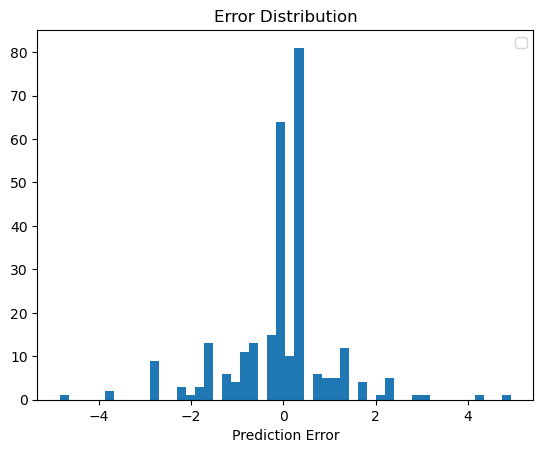

In [1134]:
errors = np.abs(y_test - y_pred)

# Top 10 worst predictions
worst_indices = np.argsort(errors)[-10:][::-1]

print("Idx | Actual | Predicted | Error")
print("-" * 40)
for i in worst_indices:
    print(f"{i:4d} | {y_test[i]:7.4f} | {y_pred[i]:9.4f} | {errors[i]:.4f}")

# Error distribution plot
plt.hist(y_test - y_pred, bins=50)
plt.xlabel('Prediction Error')
plt.title('Error Distribution')
plt.legend()
plt.show()

### Feature Importance

In [1135]:
zipped = zip(attributes, dt_reg_Fitness_Endurance.feature_importances_)
zipped = sorted(zipped, key=lambda x: x[1], reverse=True)
for col, imp in zipped:
    print(col, imp)

FGC-FGC_CORE_CAL 0.4005049324682539
Physical-Weight 0.357464903290886
CGAS-CGAS_Score 0.24203016424086007
BIA-BIA_FFMI 0.0


## TARGET VARIABLE FGC-FGC_TL

In [1170]:
df_FGC_TL= df[[
'FGC-FGC_TL',
'FGC-FGC_CORE_CAL',
'FGC-FGC_SR_CAL',
'BIA-BIA_ECW'
]]




In [1171]:
df_FGC_TL=df_FGC_TL.dropna()

In [1172]:
df_FGC_TL.isnull().sum()

FGC-FGC_TL          0
FGC-FGC_CORE_CAL    0
FGC-FGC_SR_CAL      0
BIA-BIA_ECW         0
dtype: int64

### Partitioning

In [1173]:
attributes = [col for col in df_FGC_TL.columns if col != 'FGC-FGC_TL']
X = df_FGC_TL[attributes].values
y = np.array(df_FGC_TL['FGC-FGC_TL'])

In [1174]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)


In [1175]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(1280, 3) (427, 3) (1280,) (427,)


In [1176]:
df_FGC_TL.shape

(1707, 4)

### Randomized Search

In [1177]:
# options for scoring
#scoring='neg_mean_squared_error'      # most common, minimizes large errors
#scoring='neg_mean_absolute_error'     # more robust to outliers
#scoring='neg_root_mean_squared_error' # directly in target units
#scoring='r2'                          # maximizes explained variance

In [1178]:
param_list = {
    'max_depth': [None] + list(np.arange(2, 50)),
    'min_samples_split': [0.001, 0.002, 0.01, 0.05, 0.1, 0.2],
    'min_samples_leaf': [5, 10, 20, 30, 50, 100, 150],
    'criterion': ['squared_error', 'absolute_error', 'friedman_mse']  
}

dt_reg_FGC_TL = DecisionTreeRegressor()  

random_search = RandomizedSearchCV(
    DecisionTreeRegressor(),    
    param_distributions=param_list,
    cv=KFold(n_splits=5, shuffle=True, random_state=0), 
    scoring='neg_mean_squared_error' ,   
    n_jobs=-1,
    refit=True,
    n_iter=300,
)

random_search.fit(X_train, y_train)
dt_reg_FGC_TL = random_search.best_estimator_

In [1179]:
print(random_search.best_params_, random_search.best_score_)

{'min_samples_split': 0.2, 'min_samples_leaf': 50, 'max_depth': 20, 'criterion': 'squared_error'} -6.565528151706735


In [1180]:
dt_reg_FGC_TL = random_search.best_estimator_
dt_reg_FGC_TL.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=20, min_samples_leaf=50, min_samples_split=0.2)

In [1181]:
y_pred = dt_reg_FGC_TL.predict(X_test)

print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}") # Typical error
print(f"MAE  : {mean_absolute_error(y_test, y_pred):.4f}")  #Average Error
print(f"MSE  : {mean_squared_error(y_test, y_pred):.4f}")  #Average Error
print(f"R²   : {r2_score(y_test, y_pred):.4f}") # variance in the target variable

RMSE : 2.7540
MAE  : 2.1990
MSE  : 7.5845
R²   : 0.1458


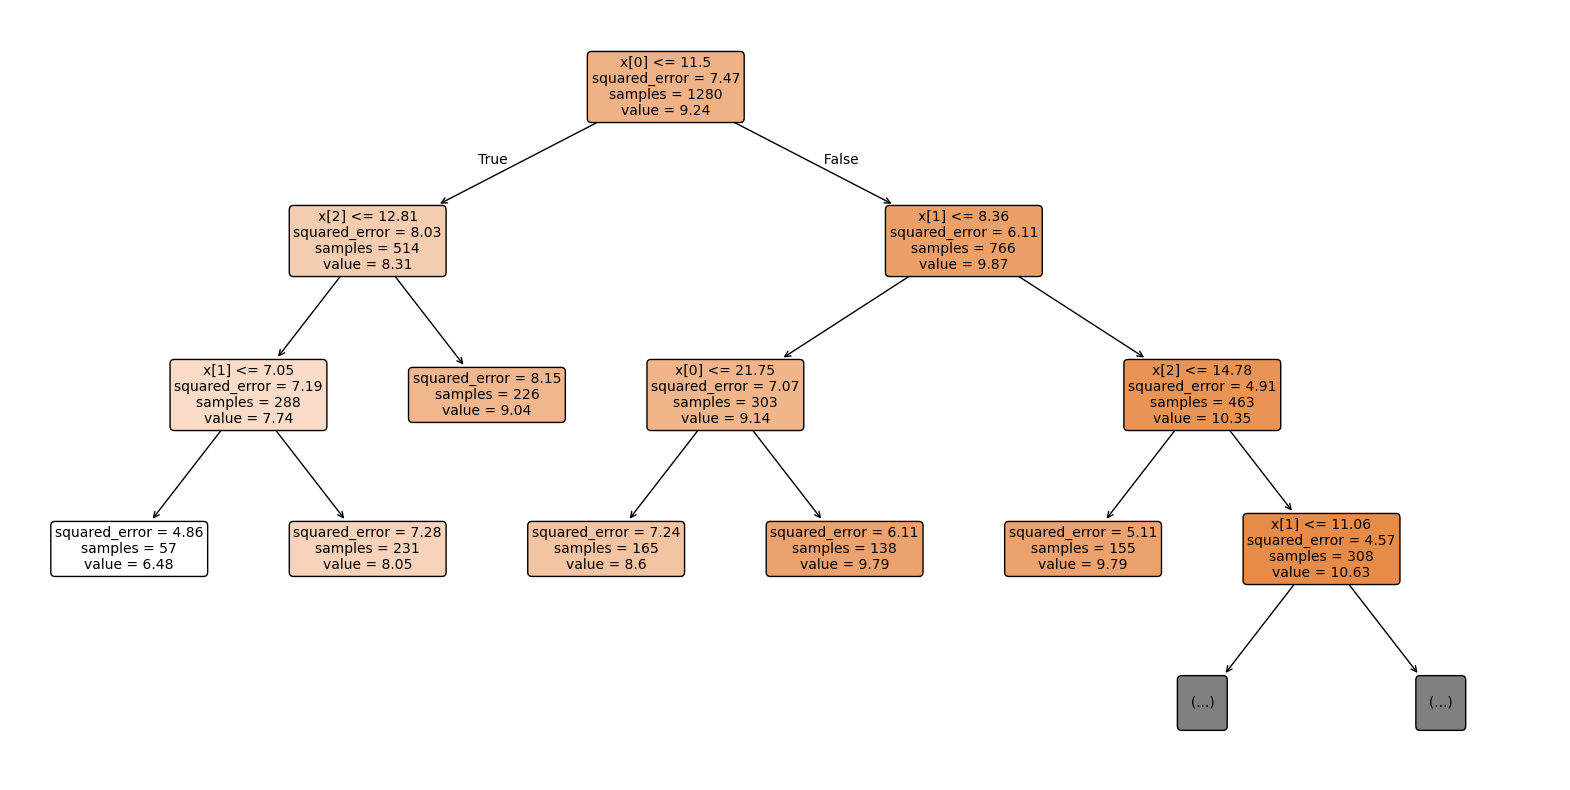

In [1182]:
plt.figure(figsize=(20, 10))

plot_tree(
    dt_reg_FGC_TL,
    filled=True,
    rounded=True,
    fontsize=10,
    precision=2,
    max_depth = 3
)

plt.show()

Idx | Actual | Predicted | Error
----------------------------------------
  43 |  0.0000 |    9.7899 | 9.7899
  38 | 19.0000 |    9.7899 | 9.2101
 296 |  0.0000 |    8.0455 | 8.0455
 242 | 17.0000 |    9.7899 | 7.2101
 115 |  2.0000 |    9.0398 | 7.0398
 361 | 18.0000 |   10.9876 | 7.0124
 270 | 16.0000 |    9.0398 | 6.9602
  25 |  3.0000 |    9.7899 | 6.7899
 187 |  0.0000 |    6.4825 | 6.4825
 382 | 15.0000 |    8.6042 | 6.3958


C:\Users\paula\AppData\Local\Temp\ipykernel_11332\1016786874.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


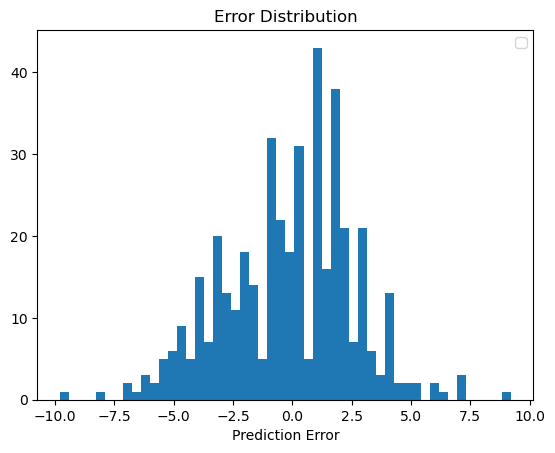

In [1183]:
errors = np.abs(y_test - y_pred)

# Top 10 worst predictions
worst_indices = np.argsort(errors)[-10:][::-1]

print("Idx | Actual | Predicted | Error")
print("-" * 40)
for i in worst_indices:
    print(f"{i:4d} | {y_test[i]:7.4f} | {y_pred[i]:9.4f} | {errors[i]:.4f}")

# Error distribution plot
plt.hist(y_test - y_pred, bins=50)
plt.xlabel('Prediction Error')
plt.title('Error Distribution')
plt.legend()
plt.show()

### Feature Importance

In [1184]:
zipped = zip(attributes, dt_reg_FGC_TL.feature_importances_)
zipped = sorted(zipped, key=lambda x: x[1], reverse=True)
for col, imp in zipped:
    print(col, imp)

FGC-FGC_CORE_CAL 0.552694574587954
FGC-FGC_SR_CAL 0.2617985846744925
BIA-BIA_ECW 0.1855068407375534


## TARGET VARIABLE SDS-SDS_Total_T

In [1257]:
df_SDS_Total= df[[
'SDS-SDS_Total_T',
'Basic_Demos-Age','Basic_Demos-Sex', 'Physical-Weight',
'Physical-Height','BIA-BIA_FMI','BIA-BIA_FFMI',
]]




In [1258]:
df_SDS_Total=df_SDS_Total.dropna()

In [1259]:
df_SDS_Total.isnull().sum()

SDS-SDS_Total_T    0
Basic_Demos-Age    0
Basic_Demos-Sex    0
Physical-Weight    0
Physical-Height    0
BIA-BIA_FMI        0
BIA-BIA_FFMI       0
dtype: int64

### Partitioning

In [1260]:
attributes = [col for col in df_SDS_Total.columns if col != 'SDS-SDS_Total_T']
X = df_SDS_Total[attributes].values
y = np.array(df_SDS_Total['SDS-SDS_Total_T'])

In [1261]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)


In [1262]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(1194, 6) (399, 6) (1194,) (399,)


In [1263]:
df_SDS_Total.shape

(1593, 7)

### Randomized Search

In [1264]:
# options for scoring
#scoring='neg_mean_squared_error'      # most common, minimizes large errors
#scoring='neg_mean_absolute_error'     # more robust to outliers
#scoring='neg_root_mean_squared_error' # directly in target units
#scoring='r2'                          # maximizes explained variance

In [1265]:
param_list = {
    'max_depth': [None] + list(np.arange(10, 50)),
    'min_samples_split': [0.001, 0.002, 0.01, 0.05, 0.1, 0.2],
    'min_samples_leaf': [5, 10, 20, 30, 50, 100, 150],
    'criterion': ['squared_error', 'absolute_error', 'friedman_mse']  
}

dt_reg_SDS_Total = DecisionTreeRegressor()  

random_search = RandomizedSearchCV(
    DecisionTreeRegressor(),    
    param_distributions=param_list,
    cv=KFold(n_splits=5, shuffle=True, random_state=0), 
    scoring='neg_mean_squared_error' ,   
    n_jobs=-1,
    refit=True,
    n_iter=300,
)

random_search.fit(X_train, y_train)
dt_reg_SDS_Total = random_search.best_estimator_

In [1266]:
print(random_search.best_params_, random_search.best_score_)

{'min_samples_split': 0.01, 'min_samples_leaf': 150, 'max_depth': 39, 'criterion': 'friedman_mse'} -178.70670499660747


In [1267]:
dt_reg_SDS_Total = random_search.best_estimator_
dt_reg_SDS_Total.fit(X_train, y_train)

DecisionTreeRegressor(criterion='friedman_mse', max_depth=39,
                      min_samples_leaf=150, min_samples_split=0.01)

In [1268]:
y_pred = dt_reg_SDS_Total.predict(X_test)

print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}") # Typical error
print(f"MAE  : {mean_absolute_error(y_test, y_pred):.4f}")  #Average Error
print(f"MSE  : {mean_squared_error(y_test, y_pred):.4f}")  #Average Error
print(f"R²   : {r2_score(y_test, y_pred):.4f}") # variance in the target variable

RMSE : 13.0766
MAE  : 10.1735
MSE  : 170.9967
R²   : -0.0225


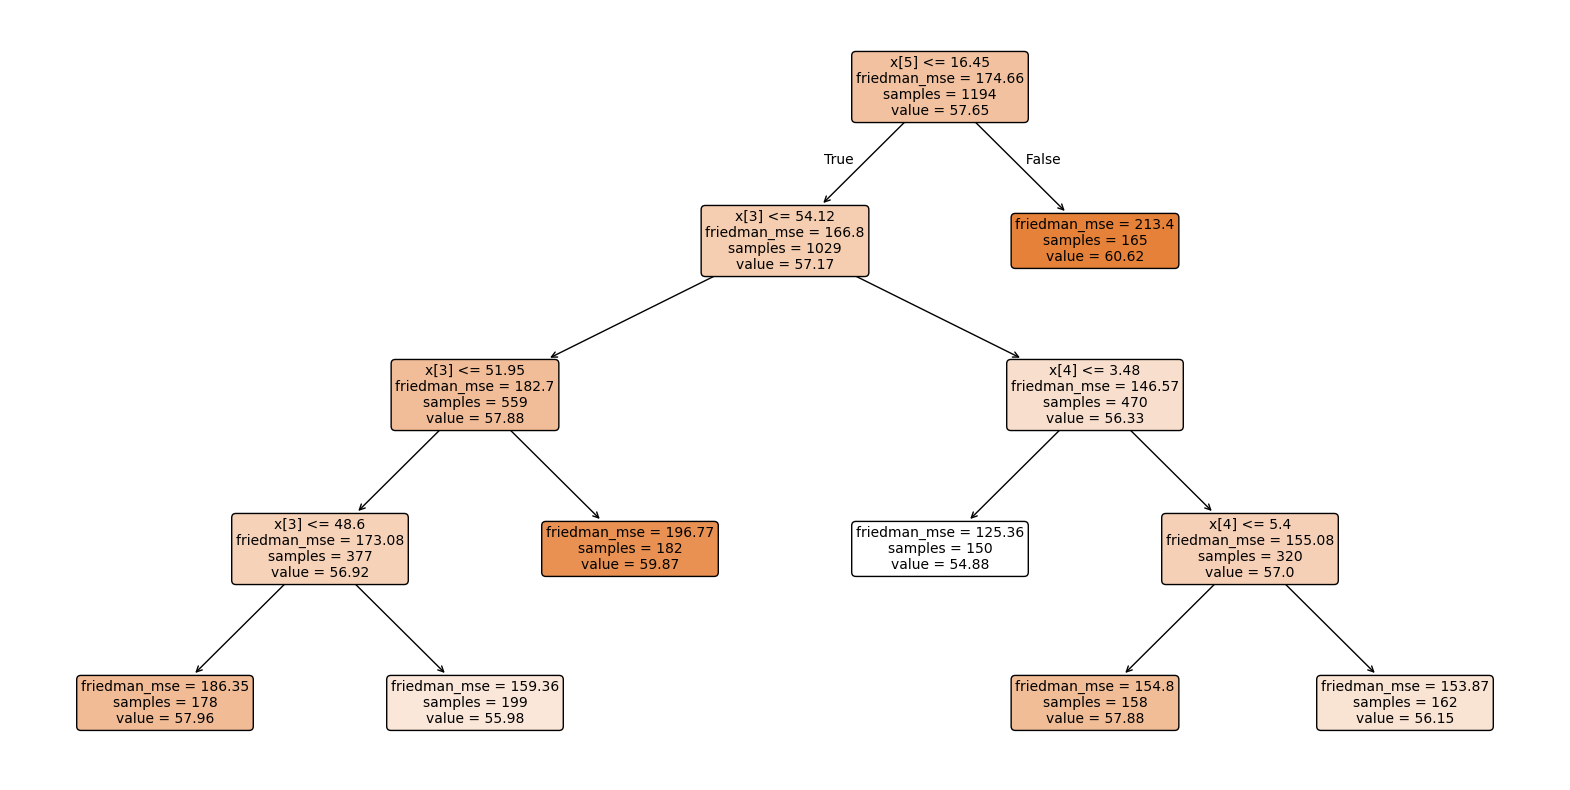

In [1269]:
plt.figure(figsize=(20, 10))

plot_tree(
    dt_reg_SDS_Total,
    filled=True,
    rounded=True,
    fontsize=10,
    precision=2,
    max_depth = 4
)

plt.show()

Idx | Actual | Predicted | Error
----------------------------------------
 204 | 100.0000 |   54.8800 | 45.1200
 306 | 100.0000 |   55.9849 | 44.0151
  40 | 100.0000 |   55.9849 | 44.0151
 357 | 100.0000 |   57.8797 | 42.1203
 245 | 100.0000 |   57.9607 | 42.0393
 340 | 99.0000 |   59.8681 | 39.1319
 127 | 94.0000 |   54.8800 | 39.1200
 339 | 95.0000 |   59.8681 | 35.1319
 101 | 91.0000 |   55.9849 | 35.0151
 123 | 90.0000 |   55.9849 | 34.0151


C:\Users\paula\AppData\Local\Temp\ipykernel_11332\1016786874.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


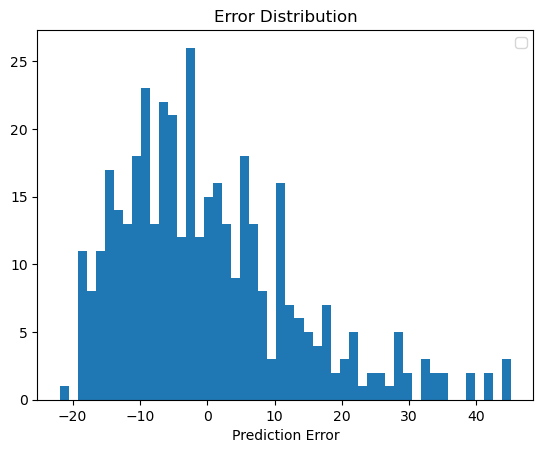

In [1270]:
errors = np.abs(y_test - y_pred)

# Top 10 worst predictions
worst_indices = np.argsort(errors)[-10:][::-1]

print("Idx | Actual | Predicted | Error")
print("-" * 40)
for i in worst_indices:
    print(f"{i:4d} | {y_test[i]:7.4f} | {y_pred[i]:9.4f} | {errors[i]:.4f}")

# Error distribution plot
plt.hist(y_test - y_pred, bins=50)
plt.xlabel('Prediction Error')
plt.title('Error Distribution')
plt.legend()
plt.show()

### Feature Importance

In [1271]:
zipped = zip(attributes, dt_reg_SDS_Total.feature_importances_)
zipped = sorted(zipped, key=lambda x: x[1], reverse=True)
for col, imp in zipped:
    print(col, imp)

Physical-Height 0.4616284276762882
BIA-BIA_FFMI 0.38076547962672297
BIA-BIA_FMI 0.1576060926969888
Basic_Demos-Age 0.0
Basic_Demos-Sex 0.0
Physical-Weight 0.0


## TARGET VARIABLE PreInt_EduHx-computerinternet_hoursday'

In [1319]:
df_computerinternet= df[[
'Basic_Demos-Age', 'CGAS-CGAS_Score', 
       'Physical-Height', 'Physical-Weight', 'BIA-BIA_BMR',
       'Physical-HeartRate', 'FGC-FGC_TL',
       'BIA-BIA_Frame_num', 'BIA-BIA_SMM', 'BIA-BIA_TBW',
       'PreInt_EduHx-computerinternet_hoursday'
]]



In [1320]:
df_computerinternet=df_computerinternet.dropna()

In [1321]:
df_computerinternet.isnull().sum()

Basic_Demos-Age                           0
CGAS-CGAS_Score                           0
Physical-Height                           0
Physical-Weight                           0
BIA-BIA_BMR                               0
Physical-HeartRate                        0
FGC-FGC_TL                                0
BIA-BIA_Frame_num                         0
BIA-BIA_SMM                               0
BIA-BIA_TBW                               0
PreInt_EduHx-computerinternet_hoursday    0
dtype: int64

### Partitioning

In [1322]:
attributes = [col for col in df_computerinternet.columns if col != 'PreInt_EduHx-computerinternet_hoursday']
X = df_computerinternet[attributes].values
y = np.array(df_computerinternet['PreInt_EduHx-computerinternet_hoursday'])

In [1323]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)


In [1324]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(1138, 10) (380, 10) (1138,) (380,)


In [1325]:
df_computerinternet.shape

(1518, 11)

### Randomized Search

In [1326]:
# options for scoring
#scoring='neg_mean_squared_error'      # most common, minimizes large errors
#scoring='neg_mean_absolute_error'     # more robust to outliers
#scoring='neg_root_mean_squared_error' # directly in target units
#scoring='r2'                          # maximizes explained variance

In [1327]:
param_list = {
    'max_depth': [None] + list(np.arange(10, 50)),
    'min_samples_split': [0.001, 0.002, 0.01, 0.05, 0.1, 0.2],
    'min_samples_leaf': [5, 10, 20, 30, 50, 100, 150],
    'criterion': ['squared_error', 'absolute_error', 'friedman_mse']  
}

dt_reg_computerinternet = DecisionTreeRegressor()  

random_search = RandomizedSearchCV(
    DecisionTreeRegressor(),    
    param_distributions=param_list,
    cv=KFold(n_splits=5, shuffle=True, random_state=0), 
    scoring='neg_mean_squared_error' ,   
    n_jobs=-1,
    refit=True,
    n_iter=300,
)

random_search.fit(X_train, y_train)
dt_reg_computerinternet = random_search.best_estimator_

In [1328]:
print(random_search.best_params_, random_search.best_score_)

{'min_samples_split': 0.05, 'min_samples_leaf': 150, 'max_depth': 19, 'criterion': 'squared_error'} -0.938830584832077


In [1329]:
dt_reg_computerinternet = random_search.best_estimator_
dt_reg_computerinternet.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=19, min_samples_leaf=150,
                      min_samples_split=0.05)

In [1330]:
y_pred = dt_reg_computerinternet.predict(X_test)

print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}") # Typical error
print(f"MAE  : {mean_absolute_error(y_test, y_pred):.4f}")  #Average Error
print(f"MSE  : {mean_squared_error(y_test, y_pred):.4f}")  #Average Error
print(f"R²   : {r2_score(y_test, y_pred):.4f}") # variance in the target variable

RMSE : 0.9412
MAE  : 0.8117
MSE  : 0.8859
R²   : 0.1583


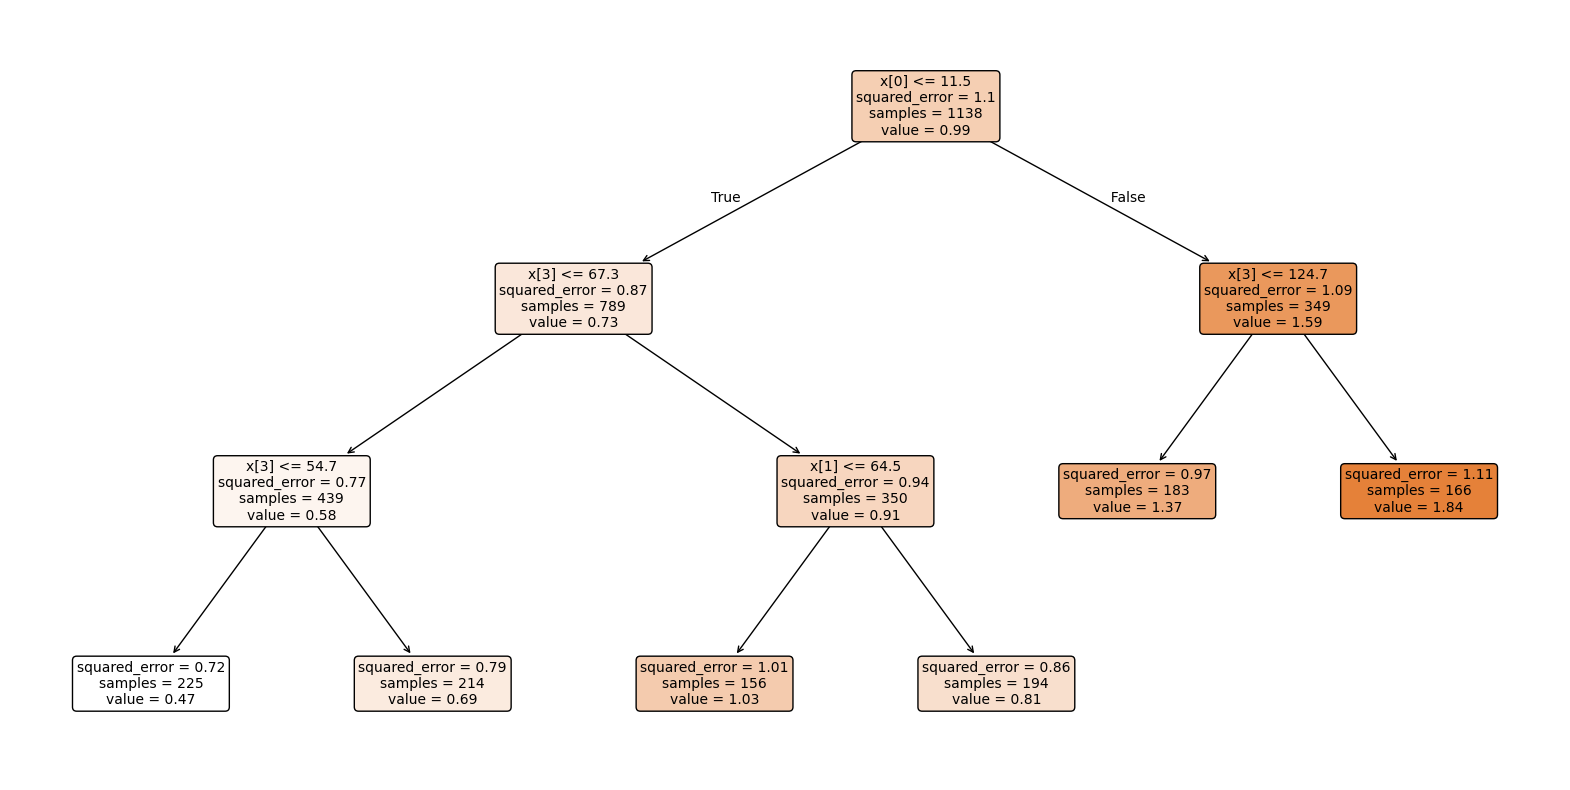

In [1331]:
plt.figure(figsize=(20, 10))

plot_tree(
    dt_reg_computerinternet,
    filled=True,
    rounded=True,
    fontsize=10,
    precision=2,
    max_depth = 4
)

plt.show()

Idx | Actual | Predicted | Error
----------------------------------------
 291 |  3.0000 |    0.6916 | 2.3084
  29 |  3.0000 |    0.6916 | 2.3084
  31 |  3.0000 |    0.8144 | 2.1856
 134 |  3.0000 |    0.8144 | 2.1856
 190 |  3.0000 |    0.8144 | 2.1856
 122 |  3.0000 |    1.0321 | 1.9679
 315 |  3.0000 |    1.0321 | 1.9679
  39 |  3.0000 |    1.0321 | 1.9679
 345 |  3.0000 |    1.0321 | 1.9679
 188 |  0.0000 |    1.8373 | 1.8373


C:\Users\paula\AppData\Local\Temp\ipykernel_11332\1016786874.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


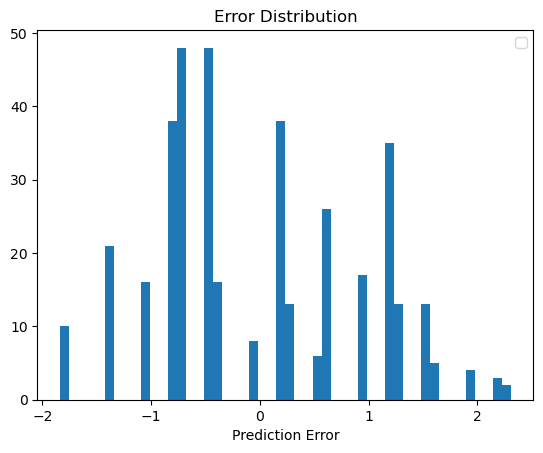

In [1332]:
errors = np.abs(y_test - y_pred)

# Top 10 worst predictions
worst_indices = np.argsort(errors)[-10:][::-1]

print("Idx | Actual | Predicted | Error")
print("-" * 40)
for i in worst_indices:
    print(f"{i:4d} | {y_test[i]:7.4f} | {y_pred[i]:9.4f} | {errors[i]:.4f}")

# Error distribution plot
plt.hist(y_test - y_pred, bins=50)
plt.xlabel('Prediction Error')
plt.title('Error Distribution')
plt.legend()
plt.show()

### Feature Importance

In [1333]:
zipped = zip(attributes, dt_reg_computerinternet.feature_importances_)
zipped = sorted(zipped, key=lambda x: x[1], reverse=True)
for col, imp in zipped:
    print(col, imp)

Basic_Demos-Age 0.784727451600078
Physical-Weight 0.19760068652452992
CGAS-CGAS_Score 0.017671861875392197
Physical-Height 0.0
BIA-BIA_BMR 0.0
Physical-HeartRate 0.0
FGC-FGC_TL 0.0
BIA-BIA_Frame_num 0.0
BIA-BIA_SMM 0.0
BIA-BIA_TBW 0.0


# IMPORT TOTAL DATASET

In [85]:
file_path = "../1.DATASET/CMI_V2.csv"
df_notna=pd.read_csv(file_path)
df_notna

,id,Basic_Demos-Age,Basic_Demos-Sex,CGAS-CGAS_Score,Physical-BMI,Physical-Height,Physical-Weight,Physical-HeartRate,Fitness_Endurance-Max_Stage,FGC-FGC_TL,...,BIA-BIA_Frame_num,BIA-BIA_SMM,BIA-BIA_TBW,SDS-SDS_Total_T,PreInt_EduHx-computerinternet_hoursday,sii,Physical-MAP_CAL,FGC-FGC_CORE_CAL,FGC-FGC_GS_CAL,FGC-FGC_SR_CAL
0,0,5,0,51.0,16.877316,46.00,50.8,NaN,5.0,6.0,...,1.0,19.541300,32.690900,NaN,3.0,2.0,82.152821,4.611111,17.883041,6.500000
1,1,9,0,NaN,14.035590,48.00,46.0,70.0,NaN,3.0,...,1.0,15.410700,27.055200,64.0,0.0,0.0,90.666667,8.000000,18.204545,11.000000
2,2,10,1,71.0,16.648696,56.50,75.6,94.0,5.0,5.0,...,NaN,NaN,44.987000,54.0,2.0,0.0,82.333333,27.000000,12.450000,10.000000
3,3,9,0,71.0,18.292347,56.00,81.6,97.0,6.0,7.0,...,2.0,26.479800,45.996600,45.0,0.0,1.0,79.000000,23.000000,18.204545,7.000000
4,4,18,1,65.0,17.937682,NaN,77.0,NaN,NaN,10.0,...,2.0,NaN,NaN,NaN,1.0,0.0,90.152104,12.000000,26.463732,8.003205
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8455,8455,7,1,NaN,16.130585,46.07,49.0,82.5,2.5,8.0,...,1.0,NaN,31.583004,55.0,0.0,0.0,81.861037,6.500000,18.075000,7.000000
8456,8456,10,1,69.5,17.300000,56.13,47.8,80.5,5.0,8.0,...,1.0,22.983200,36.475662,NaN,0.0,1.0,79.833333,8.500000,13.575000,5.000000
8457,8457,10,1,70.0,40.937571,49.56,47.2,83.5,7.0,NaN,...,2.0,31.594712,35.106855,NaN,2.0,0.0,82.166667,21.500000,16.840263,9.500000
8458,8458,15,1,55.5,22.500000,63.79,99.5,87.5,NaN,9.0,...,2.0,46.467581,57.530686,NaN,1.0,2.0,88.395702,10.000000,26.417470,10.500000


In [86]:
df_notna.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8460 entries, 0 to 8459
Data columns (total 31 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   id                                      8460 non-null   int64  
 1   Basic_Demos-Age                         8460 non-null   int64  
 2   Basic_Demos-Sex                         8460 non-null   int64  
 3   CGAS-CGAS_Score                         7034 non-null   float64
 4   Physical-BMI                            8460 non-null   float64
 5   Physical-Height                         7595 non-null   float64
 6   Physical-Weight                         7641 non-null   float64
 7   Physical-HeartRate                      7539 non-null   float64
 8   Fitness_Endurance-Max_Stage             5480 non-null   float64
 9   FGC-FGC_TL                              6945 non-null   float64
 10  BIA-BIA_Activity_Level_num              6636 non-null   floa

# REPLACE NULL VALUES

## 'Physical-Height'

In [87]:
attributes = ['id','Physical-BMI','Physical-Height', 'Physical-Weight']
df_unknown=df_notna[attributes][df_notna['Physical-Height'].isna()].copy()
df_unknown.isnull().sum()

id                   0
Physical-BMI         0
Physical-Height    865
Physical-Weight    260
dtype: int64

In [88]:
#df_unknown=df_unknown.dropna(subset=['Physical-Weight', 
#                'Physical-Height','BIA-BIA_FMI','BIA-BIA_FFMI'])
df_unknown.isnull().sum()

id                   0
Physical-BMI         0
Physical-Height    865
Physical-Weight    260
dtype: int64

In [89]:
attributes = [col for col in df_unknown.columns if col not in ['Physical-Height','id']]
X_unknown = df_unknown[attributes].values
predicted_value = dt_reg_height.predict(X_unknown)

In [90]:
df_unknown['Physical-Height_DT'] = predicted_value
df_unknown=df_unknown[['id','Physical-Height_DT']]
df_unknown

,id,Physical-Height_DT
4,4,54.626000
26,26,59.125000
30,30,52.992857
35,35,50.722222
42,42,54.626000
...,...,...
8408,8408,63.500000
8435,8435,62.857143
8437,8437,69.750000
8447,8447,57.840000


In [ ]:
df_notna=df_notna.merge(df_unknown,on=['id'],how="left")
df_notna.loc[((df_notna['Physical-Height'].isnull()) | (df_notna['Physical-Height']==0)) , 'Physical-Height'] = df_notna['Physical-Height_DT']
df_notna.isnull().sum()

id                                           0
Basic_Demos-Age                              0
Basic_Demos-Sex                              0
CGAS-CGAS_Score                           1426
Physical-BMI                                 0
Physical-Height                              0
Physical-Weight                            819
Physical-HeartRate                         921
Fitness_Endurance-Max_Stage               2980
FGC-FGC_TL                                1515
BIA-BIA_Activity_Level_num                1824
BIA-BIA_BMI                               1824
BIA-BIA_BMC                               1824
BIA-BIA_DEE                               1824
BIA-BIA_ECW                               1824
BIA-BIA_ICW                               1824
BIA-BIA_FFMI                              1824
BIA-BIA_FFM                               1824
BIA-BIA_FMI                               1824
BIA-BIA_Fat                               1824
BIA-BIA_LST                               1824
BIA-BIA_Frame

## 'Physical-Weight'

In [92]:
df_notna.loc[((df_notna['Physical-Weight'].isnull())) , 'Physical-Weight'] = (df_notna['Physical-BMI']/703)*(df_notna['Physical-Height']*df_notna['Physical-Height'])

In [93]:
df_notna.isnull().sum()

id                                           0
Basic_Demos-Age                              0
Basic_Demos-Sex                              0
CGAS-CGAS_Score                           1426
Physical-BMI                                 0
Physical-Height                              0
Physical-Weight                              0
Physical-HeartRate                         921
Fitness_Endurance-Max_Stage               2980
FGC-FGC_TL                                1515
BIA-BIA_Activity_Level_num                1824
BIA-BIA_BMI                               1824
BIA-BIA_BMC                               1824
BIA-BIA_DEE                               1824
BIA-BIA_ECW                               1824
BIA-BIA_ICW                               1824
BIA-BIA_FFMI                              1824
BIA-BIA_FFM                               1824
BIA-BIA_FMI                               1824
BIA-BIA_Fat                               1824
BIA-BIA_LST                               1824
BIA-BIA_Frame

## 'Physical-Height'

In [ ]:
attributes = ['id','Physical-BMI','Physical-Height', 'Physical-Weight']
df_unknown=df_notna[attributes][df_notna['Physical-Height'].isna()].copy()
df_unknown.isnull().sum()

id                   0
Physical-BMI         0
Physical-Height    865
Physical-Weight    260
dtype: int64

In [ ]:
#df_unknown=df_unknown.dropna(subset=['Physical-Weight', 
#                'Physical-Height','BIA-BIA_FMI','BIA-BIA_FFMI'])
df_unknown.isnull().sum()

id                   0
Physical-BMI         0
Physical-Height    865
Physical-Weight    260
dtype: int64

In [ ]:
attributes = [col for col in df_unknown.columns if col not in ['Physical-Height','id']]
X_unknown = df_unknown[attributes].values
predicted_value = dt_reg_height.predict(X_unknown)

In [ ]:
df_unknown['Physical-Height_DT'] = predicted_value
df_unknown=df_unknown[['id','Physical-Height_DT']]
df_unknown

,id,Physical-Height_DT
4,4,54.626000
26,26,59.125000
30,30,52.992857
35,35,50.722222
42,42,54.626000
...,...,...
8408,8408,63.500000
8435,8435,62.857143
8437,8437,69.750000
8447,8447,57.840000


In [ ]:
df_notna=df_notna.merge(df_unknown,on=['id'],how="left")
df_notna.loc[((df_notna['Physical-Height'].isnull())) , 'Physical-Height'] = df_notna['Physical-Height_DT']
df_notna.isnull().sum()

id                                           0
Basic_Demos-Age                              0
Basic_Demos-Sex                              0
CGAS-CGAS_Score                           1426
Physical-BMI                                 0
Physical-Height                              0
Physical-Weight                            819
Physical-HeartRate                         921
Fitness_Endurance-Max_Stage               2980
FGC-FGC_TL                                1515
BIA-BIA_Activity_Level_num                1824
BIA-BIA_BMI                               1824
BIA-BIA_BMC                               1824
BIA-BIA_DEE                               1824
BIA-BIA_ECW                               1824
BIA-BIA_ICW                               1824
BIA-BIA_FFMI                              1824
BIA-BIA_FFM                               1824
BIA-BIA_FMI                               1824
BIA-BIA_Fat                               1824
BIA-BIA_LST                               1824
BIA-BIA_Frame

# not null dataset 

In [94]:
df_notna.shape

(8460, 32)

In [95]:
df_notna=df_notna.drop(columns = 
  ['Physical-Height_DT'])

In [96]:
df_notna.columns



Index(['id', 'Basic_Demos-Age', 'Basic_Demos-Sex', 'CGAS-CGAS_Score',
       'Physical-BMI', 'Physical-Height', 'Physical-Weight',
       'Physical-HeartRate', 'Fitness_Endurance-Max_Stage', 'FGC-FGC_TL',
       'BIA-BIA_Activity_Level_num', 'BIA-BIA_BMI', 'BIA-BIA_BMC',
       'BIA-BIA_DEE', 'BIA-BIA_ECW', 'BIA-BIA_ICW', 'BIA-BIA_FFMI',
       'BIA-BIA_FFM', 'BIA-BIA_FMI', 'BIA-BIA_Fat', 'BIA-BIA_LST',
       'BIA-BIA_Frame_num', 'BIA-BIA_SMM', 'BIA-BIA_TBW', 'SDS-SDS_Total_T',
       'PreInt_EduHx-computerinternet_hoursday', 'sii', 'Physical-MAP_CAL',
       'FGC-FGC_CORE_CAL', 'FGC-FGC_GS_CAL', 'FGC-FGC_SR_CAL'],
      dtype='object')

In [97]:
df_notna.to_csv('../1.DATASET/CMI_NN_V1.csv', index=False)